# E15: Gene correlations

**Started:** March 16, 2026

**Last updated:** March 17, 2026

**Research questions:** Specifically, are top correlated orthologs shared across mice and humans? Generally, are genetic relationships across mice and humans partially shared? 

**Hypothesis:** A subset of orthologs within each species correlate similarly across species, with at least 100 orthologs showing similar correlation structure across species.

**Conclusion:** TBD

**Potential Next Steps:** TBD

In [1]:
from __future__ import annotations
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy as sp
from scipy.spatial.distance import cdist
from scipy import sparse
from scipy.stats import pearsonr
import ot
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
from __future__ import annotations
from typing import Any, Dict, Hashable, Iterable, List, Sequence, Tuple, Union, Optional
from speciesot_helpers import label_uniform_cell_type_row, \
                              top_n_organisms_from_species, \
                              cell_types_with_n_per_organism, \
                              sample_equal_cell_types, \
                              ot_between_organisms, \
                              calc_random_mean_std, \
                              test_train_split_adata, \
                              get_cell_type_from_index, \
                              create_label_to_sample_dicts, \
                              concat_index, \
                              show_cell_type_results, \
                              cell_type_knn_acc, \
                              split_adata_by_celltype_tissue, \
                              match_cells_by_celltype_tissue, \
                              combine_transport_plans, \
                              convert_ensembl_to_gene_symbols, \
                              nearest_neighbor_cell_type, \
                              nn_gene_r2, \
                              plot_ot_transport_by_celltype
from speciesot_simulation_helpers import run_ot, \
                                         compute_mapping_acc, \
                                         sublabel_match_rate_from_gw, \
                                         plot_got_best_matches_with_labels, \
                                         gw_seeded, \
                                         plot_first_two_dims

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
human_dir = 'data/tabula_sapiens/'
mouse_dir = 'data/tabula_muris/'

In [3]:
human_adatas = top_n_organisms_from_species(human_dir, 2, 'human')
mouse_adatas = top_n_organisms_from_species(mouse_dir, 2, 'mouse')

In [4]:
human_adatas_all = top_n_organisms_from_species(human_dir, -1, 'human')

In [5]:
mouse_adatas_all = top_n_organisms_from_species(mouse_dir, -1, 'mouse')

In [6]:
human_combined = ad.concat(human_adatas_all, join="outer")

In [7]:
mouse_combined = ad.concat(mouse_adatas_all, join="outer")

In [8]:
mouse1, human1 =  match_cells_by_celltype_tissue(mouse_combined, human_combined)

In [9]:
human1.obs[['cell_type_ontology_term_id','tissue_ontology_term_id']].value_counts()

cell_type_ontology_term_id  tissue_ontology_term_id
CL:0008001                  UBERON:0002371             792
CL:0000037                  UBERON:0002371             721
CL:0002393                  UBERON:0002048             504
CL:0000893                  UBERON:0002370             455
CL:0000875                  UBERON:0002048             426
                                                      ... 
CL:0000084                  UBERON:0002107               2
CL:0000576                  UBERON:0000948               2
CL:0000232                  UBERON:0000948               1
CL:0000084                  UBERON:0003126               1
CL:0000624                  UBERON:0002107               1
Name: count, Length: 75, dtype: int64

In [10]:
mouse1.obs[['cell_type_ontology_term_id','tissue_ontology_term_id']].value_counts()

cell_type_ontology_term_id  tissue_ontology_term_id
CL:0008001                  UBERON:0002371             792
CL:0000037                  UBERON:0002371             721
CL:0002393                  UBERON:0002048             504
CL:0000893                  UBERON:0002370             455
CL:0000875                  UBERON:0002048             426
                                                      ... 
CL:0000084                  UBERON:0002107               2
CL:0000576                  UBERON:0000948               2
CL:0000232                  UBERON:0000948               1
CL:0000084                  UBERON:0003126               1
CL:0000624                  UBERON:0002107               1
Name: count, Length: 75, dtype: int64

In [11]:
mouse1.var = mouse_adatas[0].var.copy()

In [12]:
import re
from urllib.parse import urlparse

import pandas as pd


def mouse_human_orthologs_biomart(
    adata_h,
    adata_m,
    *,
    # If var_names are Ensembl IDs, leave these as None.
    human_ensembl_col: str | None = None,
    mouse_ensembl_col: str | None = None,
    # Optional fallback names from adata.var
    human_symbol_col: str | None = "gene_symbol",
    mouse_symbol_col: str | None = "gene_symbol",
    # BioMart options
    biomart_host: str = "www.ensembl.org",
    human_dataset: str = "hsapiens_gene_ensembl",
    one2one_only: bool = True,
    drop_duplicates: bool = True,
) -> pd.DataFrame:
    """
    Return a pandas DataFrame of overlapping human↔mouse orthologs between two AnnData objects.

    Output columns:
      mouse_gene_name
      human_gene_name
      mouse_ensembl_id
      human_ensembl_id
      orthology_type

    Notes
    -----
    - If `human_ensembl_col` / `mouse_ensembl_col` are None, `adata.var_names` are assumed
      to contain Ensembl IDs.
    - Ensembl version suffixes like '.12' are stripped automatically.
    - Human is queried from Ensembl BioMart, then filtered to genes present in both objects.
    """

    def strip_ensembl_version(x: str) -> str:
        return re.sub(r"\.\d+$", "", str(x).strip())

    def get_ens_series_and_symbol_series(adata, ensembl_col, symbol_col):
        if ensembl_col is None:
            ens_series = pd.Series(
                [strip_ensembl_version(x) for x in adata.var_names],
                index=adata.var_names,
                name="ensembl_id",
            )
        else:
            if ensembl_col not in adata.var.columns:
                raise KeyError(f"'{ensembl_col}' not found in adata.var")
            ens_series = adata.var[ensembl_col].astype(str).map(strip_ensembl_version)

        sym_series = None
        if symbol_col is not None and symbol_col in adata.var.columns:
            sym_series = adata.var[symbol_col].astype(str)

        return ens_series, sym_series

    def build_first_index_map(ens_series: pd.Series) -> dict[str, int]:
        out = {}
        for i, eid in enumerate(ens_series.values):
            if eid and eid.lower() != "nan" and eid not in out:
                out[eid] = i
        return out

    def pick_name(biomart_name, fallback_sym_series, fallback_idx, fallback_id):
        if biomart_name is not None:
            s = str(biomart_name).strip()
            if s and s.lower() != "nan":
                return s
        if fallback_sym_series is not None:
            try:
                s = str(fallback_sym_series.iloc[fallback_idx]).strip()
                if s and s.lower() != "nan":
                    return s
            except Exception:
                pass
        return str(fallback_id)

    # Build Ensembl and symbol series from AnnData objects
    h_ens, h_sym = get_ens_series_and_symbol_series(adata_h, human_ensembl_col, human_symbol_col)
    m_ens, m_sym = get_ens_series_and_symbol_series(adata_m, mouse_ensembl_col, mouse_symbol_col)

    h_map = build_first_index_map(h_ens)
    m_map = build_first_index_map(m_ens)

    # pybiomart expects a bare host
    host = biomart_host.strip()
    if host.startswith("http://") or host.startswith("https://"):
        host = urlparse(host).netloc

    try:
        from pybiomart import Dataset
    except ModuleNotFoundError as e:
        raise ModuleNotFoundError(
            "pybiomart is not installed. Install it with `pip install pybiomart`."
        ) from e

    human = Dataset(name=human_dataset, host=host)

    attrs = [
        "ensembl_gene_id",
        "external_gene_name",
        "mmusculus_homolog_ensembl_gene",
        "mmusculus_homolog_associated_gene_name",
        "mmusculus_homolog_orthology_type",
    ]
    ortho = human.query(attributes=attrs).copy()

    # Normalize column names defensively
    col_map = {
        "ensembl_gene_id": "human_ens",
        "external_gene_name": "human_name_biomart",
        "mmusculus_homolog_ensembl_gene": "mouse_ens",
        "mmusculus_homolog_associated_gene_name": "mouse_name_biomart",
        "mmusculus_homolog_orthology_type": "orthology_type",
        "Gene stable ID": "human_ens",
        "Gene name": "human_name_biomart",
        "Mouse gene stable ID": "mouse_ens",
        "Mouse gene name": "mouse_name_biomart",
        "Mouse homology type": "orthology_type",
    }
    ortho = ortho.rename(columns={c: col_map.get(c, c) for c in ortho.columns})

    required = {"human_ens", "mouse_ens"}
    if not required.issubset(ortho.columns):
        raise RuntimeError(
            f"BioMart query did not return expected columns. Got: {list(ortho.columns)}"
        )

    ortho["human_ens"] = ortho["human_ens"].astype(str).map(strip_ensembl_version)
    ortho["mouse_ens"] = ortho["mouse_ens"].astype(str).map(strip_ensembl_version)

    # Optional one-to-one filter
    if one2one_only and "orthology_type" in ortho.columns:
        ortho = ortho[ortho["orthology_type"] == "ortholog_one2one"].copy()

    # Keep only orthologs that are present in both AnnData objects
    ortho = ortho[
        ortho["human_ens"].isin(h_map) &
        ortho["mouse_ens"].isin(m_map)
    ].copy()

    if drop_duplicates:
        ortho = ortho.drop_duplicates(subset=["human_ens", "mouse_ens"]).reset_index(drop=True)

    if ortho.empty:
        raise RuntimeError("No overlapping orthologs found between BioMart and your AnnData objects.")

    # Resolve display names
    human_names = []
    mouse_names = []
    for _, row in ortho.iterrows():
        hi = h_map[row["human_ens"]]
        mi = m_map[row["mouse_ens"]]

        human_names.append(
            pick_name(row.get("human_name_biomart"), h_sym, hi, row["human_ens"])
        )
        mouse_names.append(
            pick_name(row.get("mouse_name_biomart"), m_sym, mi, row["mouse_ens"])
        )

    res = pd.DataFrame(
        {
            "mouse_gene_name": mouse_names,
            "human_gene_name": human_names,
            "mouse_ensembl_id": ortho["mouse_ens"].values,
            "human_ensembl_id": ortho["human_ens"].values,
            "orthology_type": ortho["orthology_type"].values
            if "orthology_type" in ortho.columns
            else pd.NA,
        }
    )

    return res.sort_values(
        ["human_gene_name", "mouse_gene_name"],
        ignore_index=True,
    )

In [13]:
import re

import numpy as np
import pandas as pd
from scipy import sparse


def within_species_ortholog_pair_r2_tables(
    adata_h,
    adata_m,
    ortholog_df: pd.DataFrame,
    *,
    n_top_genes: int = 2000,
    human_ensembl_col: str | None = None,
    mouse_ensembl_col: str | None = None,
    human_symbol_col: str | None = "gene_symbol",
    mouse_symbol_col: str | None = "gene_symbol",
    layer_h: str | None = None,
    layer_m: str | None = None,
    expression_threshold: float = 0.0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build within-species gene-gene r^2 tables for human and mouse, restricted to the
    top HVGs in each species, and annotate each pair with the corresponding ortholog-pair
    r^2/rank in the other species.

    Output columns in each dataframe:
      - gene1
      - gene2
      - r2
      - r2_rank
      - other_species_r2
          * NaN if one/both genes have no ortholog
          * -2 if ortholog pair exists but cannot be evaluated because one/both orthologs
            are not in the other species top HVGs
      - other_species_r2_rank
          * NaN if one/both genes have no ortholog
          * -2 if ortholog pair exists but cannot be evaluated because one/both orthologs
            are not in the other species top HVGs
      - gene1_pct_cells_expressing
      - gene2_pct_cells_expressing
      - gene1_ortholog_pct_cells_expressing_other_species
          * NaN if gene1 has no ortholog
      - gene2_ortholog_pct_cells_expressing_other_species
          * NaN if gene2 has no ortholog

    Notes
    -----
    - Percent expressing is computed as:
          100 * fraction of cells with expression > expression_threshold
    - `gene1` and `gene2` are emitted as Ensembl IDs for unambiguous ortholog matching.
    """

    def strip_ensembl_version(x: str) -> str:
        return re.sub(r"\.\d+$", "", str(x).strip())

    def get_matrix(adata, layer):
        X = adata.layers[layer] if layer is not None else adata.X
        if sparse.issparse(X):
            return X.tocsr()
        return np.asarray(X)

    def get_ens_and_symbol(adata, ensembl_col, symbol_col):
        if ensembl_col is None:
            ens = pd.Series(
                [strip_ensembl_version(x) for x in adata.var_names],
                index=adata.var_names,
                name="ensembl_id",
            )
        else:
            if ensembl_col not in adata.var.columns:
                raise KeyError(f"'{ensembl_col}' not found in adata.var")
            ens = adata.var[ensembl_col].astype(str).map(strip_ensembl_version)

        sym = None
        if symbol_col is not None and symbol_col in adata.var.columns:
            sym = adata.var[symbol_col].astype(str)

        return ens, sym

    def compute_hvgs(adata, layer, n_top):
        try:
            import scanpy as sc
        except ModuleNotFoundError as e:
            raise ModuleNotFoundError(
                "scanpy is required for HVG selection. Install with `pip install scanpy`."
            ) from e

        if "highly_variable" in adata.var.columns and int(np.sum(adata.var["highly_variable"].values)) >= n_top:
            mask = adata.var["highly_variable"].values.astype(bool)
            idx = np.where(mask)[0]
            if len(idx) > n_top:
                if "highly_variable_rank" in adata.var.columns:
                    ranks = np.asarray(adata.var["highly_variable_rank"].values, dtype=float)
                    idx = idx[np.argsort(ranks[idx])[:n_top]]
                elif "dispersions_norm" in adata.var.columns:
                    score = np.asarray(adata.var["dispersions_norm"].values, dtype=float)
                    idx = idx[np.argsort(-score[idx])[:n_top]]
                else:
                    idx = idx[:n_top]
            return np.asarray(idx, dtype=int)

        tmp = adata.copy()
        sc.pp.highly_variable_genes(tmp, n_top_genes=n_top, layer=layer, inplace=True)
        mask = tmp.var["highly_variable"].values.astype(bool)
        idx = np.where(mask)[0]
        if len(idx) > n_top and "highly_variable_rank" in tmp.var.columns:
            ranks = np.asarray(tmp.var["highly_variable_rank"].values, dtype=float)
            idx = idx[np.argsort(ranks[idx])[:n_top]]
        return np.asarray(idx, dtype=int)

    def corr_r2_matrix(X):
        # X: cells x genes
        if sparse.issparse(X):
            X = X.toarray()
        else:
            X = np.asarray(X)

        X = X.astype(float, copy=False)

        if X.shape[0] < 2:
            raise ValueError("Need at least 2 cells to compute correlations.")

        Xc = X - X.mean(axis=0, keepdims=True)
        denom = Xc.std(axis=0, ddof=1)
        valid = denom > 0

        R = np.full((X.shape[1], X.shape[1]), np.nan, dtype=float)
        if np.any(valid):
            Z = Xc[:, valid] / denom[valid]
            C = (Z.T @ Z) / (X.shape[0] - 1)
            C = np.clip(C, -1.0, 1.0)
            R[np.ix_(valid, valid)] = C

        np.fill_diagonal(R, 1.0)
        return R * R

    def upper_triangle_pair_table(r2_mat: np.ndarray, gene_names: np.ndarray):
        n = r2_mat.shape[0]
        i, j = np.triu_indices(n, k=1)
        df = pd.DataFrame(
            {
                "gene1": gene_names[i],
                "gene2": gene_names[j],
                "r2": r2_mat[i, j],
            }
        )
        df = df.sort_values("r2", ascending=False, na_position="last", ignore_index=True)
        df["r2_rank"] = np.arange(1, len(df) + 1, dtype=int)
        return df

    def build_pair_lookup(df: pd.DataFrame) -> dict[tuple[str, str], tuple[float, int]]:
        out = {}
        for _, row in df.iterrows():
            key = tuple(sorted((str(row["gene1"]), str(row["gene2"]))))
            out[key] = (
                float(row["r2"]) if pd.notna(row["r2"]) else np.nan,
                int(row["r2_rank"]),
            )
        return out

    def percent_cells_expressing(X, threshold: float) -> np.ndarray:
        # X: cells x genes
        if sparse.issparse(X):
            # Boolean comparison remains sparse
            expr = (X > threshold)
            pct = np.asarray(expr.mean(axis=0)).ravel() * 100.0
        else:
            pct = (np.asarray(X) > threshold).mean(axis=0) * 100.0
        return np.asarray(pct, dtype=float)

    def annotate_with_other_species(
        df_this: pd.DataFrame,
        this_to_other: dict[str, str],
        other_hvg_set: set[str],
        other_pair_lookup: dict[tuple[str, str], tuple[float, int]],
        this_pct_lookup: dict[str, float],
        other_pct_lookup: dict[str, float],
    ) -> pd.DataFrame:
        n = len(df_this)

        other_r2 = np.empty(n, dtype=float)
        other_rank = np.empty(n, dtype=float)

        gene1_pct = np.empty(n, dtype=float)
        gene2_pct = np.empty(n, dtype=float)
        gene1_other_pct = np.empty(n, dtype=float)
        gene2_other_pct = np.empty(n, dtype=float)

        for k, row in enumerate(df_this.itertuples(index=False)):
            g1 = str(row.gene1)
            g2 = str(row.gene2)

            gene1_pct[k] = this_pct_lookup.get(g1, np.nan)
            gene2_pct[k] = this_pct_lookup.get(g2, np.nan)

            o1 = this_to_other.get(g1)
            o2 = this_to_other.get(g2)

            gene1_other_pct[k] = other_pct_lookup.get(o1, np.nan) if o1 is not None else np.nan
            gene2_other_pct[k] = other_pct_lookup.get(o2, np.nan) if o2 is not None else np.nan

            if o1 is None or o2 is None:
                other_r2[k] = np.nan
                other_rank[k] = np.nan
                continue

            if o1 not in other_hvg_set or o2 not in other_hvg_set:
                other_r2[k] = -2.0
                other_rank[k] = -2.0
                continue

            key = tuple(sorted((o1, o2)))
            val = other_pair_lookup.get(key)
            if val is None:
                other_r2[k] = -2.0
                other_rank[k] = -2.0
            else:
                other_r2[k] = val[0]
                other_rank[k] = val[1]

        out = df_this.copy()
        out["other_species_r2"] = other_r2
        out["other_species_r2_rank"] = other_rank
        out["gene1_pct_cells_expressing"] = gene1_pct
        out["gene2_pct_cells_expressing"] = gene2_pct
        out["gene1_ortholog_pct_cells_expressing_other_species"] = gene1_other_pct
        out["gene2_ortholog_pct_cells_expressing_other_species"] = gene2_other_pct
        return out

    # Validate ortholog table
    required_cols = {"human_ensembl_id", "mouse_ensembl_id"}
    missing = required_cols - set(ortholog_df.columns)
    if missing:
        raise KeyError(f"ortholog_df is missing required columns: {sorted(missing)}")

    # Get Ensembl IDs
    h_ens, _ = get_ens_and_symbol(adata_h, human_ensembl_col, human_symbol_col)
    m_ens, _ = get_ens_and_symbol(adata_m, mouse_ensembl_col, mouse_symbol_col)

    # Top HVGs
    h_hvg_idx = compute_hvgs(adata_h, layer_h, n_top_genes)
    m_hvg_idx = compute_hvgs(adata_m, layer_m, n_top_genes)

    # Full matrices and HVG-restricted matrices
    Xh_full = get_matrix(adata_h, layer_h)
    Xm_full = get_matrix(adata_m, layer_m)

    Xh = Xh_full[:, h_hvg_idx]
    Xm = Xm_full[:, m_hvg_idx]

    # HVG gene IDs
    h_hvg_ens = np.asarray(h_ens.iloc[h_hvg_idx].values, dtype=str)
    m_hvg_ens = np.asarray(m_ens.iloc[m_hvg_idx].values, dtype=str)

    # Use Ensembl IDs as stable identifiers
    h_gene_names = h_hvg_ens.copy()
    m_gene_names = m_hvg_ens.copy()

    # Within-species gene-gene r^2
    h_r2_mat = corr_r2_matrix(Xh)
    m_r2_mat = corr_r2_matrix(Xm)

    human_df = upper_triangle_pair_table(h_r2_mat, h_gene_names)
    mouse_df = upper_triangle_pair_table(m_r2_mat, m_gene_names)

    # Ortholog mapping
    ortho = ortholog_df[["human_ensembl_id", "mouse_ensembl_id"]].copy()
    ortho["human_ensembl_id"] = ortho["human_ensembl_id"].astype(str).map(strip_ensembl_version)
    ortho["mouse_ensembl_id"] = ortho["mouse_ensembl_id"].astype(str).map(strip_ensembl_version)
    ortho = ortho.dropna().drop_duplicates()

    # Keep only unambiguous mappings
    h_counts = ortho["human_ensembl_id"].value_counts()
    m_counts = ortho["mouse_ensembl_id"].value_counts()
    ortho = ortho[ortho["human_ensembl_id"].map(h_counts) == 1]
    ortho = ortho[ortho["mouse_ensembl_id"].map(m_counts) == 1].reset_index(drop=True)

    human_to_mouse = dict(zip(ortho["human_ensembl_id"], ortho["mouse_ensembl_id"]))
    mouse_to_human = dict(zip(ortho["mouse_ensembl_id"], ortho["human_ensembl_id"]))

    h_hvg_set = set(h_gene_names)
    m_hvg_set = set(m_gene_names)

    human_pair_lookup = build_pair_lookup(human_df)
    mouse_pair_lookup = build_pair_lookup(mouse_df)

    # Percent-expressing lookups, computed for HVGs in each species
    h_pct = percent_cells_expressing(Xh, expression_threshold)
    m_pct = percent_cells_expressing(Xm, expression_threshold)

    human_pct_lookup = dict(zip(h_gene_names, h_pct))
    mouse_pct_lookup = dict(zip(m_gene_names, m_pct))

    human_df = annotate_with_other_species(
        df_this=human_df,
        this_to_other=human_to_mouse,
        other_hvg_set=m_hvg_set,
        other_pair_lookup=mouse_pair_lookup,
        this_pct_lookup=human_pct_lookup,
        other_pct_lookup=mouse_pct_lookup,
    )

    mouse_df = annotate_with_other_species(
        df_this=mouse_df,
        this_to_other=mouse_to_human,
        other_hvg_set=h_hvg_set,
        other_pair_lookup=human_pair_lookup,
        this_pct_lookup=mouse_pct_lookup,
        other_pct_lookup=human_pct_lookup,
    )

    return human_df, mouse_df

In [14]:
ortholog_df = mouse_human_orthologs_biomart(human_combined, mouse_combined)

In [ ]:
human_corr_df, mouse_corr_df = within_species_ortholog_pair_r2_tables(mouse1, human1, ortholog_df, n_top_genes=1000)

In [ ]:
mouse_corr_df.head(20)

In [15]:
import re
import numpy as np
import pandas as pd
from scipy import sparse


def ortholog_hvg1000_gene_pair_r2(
    adata_h,
    adata_m,
    ortholog_df,
    *,
    n_top_ortholog_hvgs: int = 1000,
    human_ensembl_col=None,
    mouse_ensembl_col=None,
    mouse_symbol_col: str = "gene_symbols",
    layer_h=None,
    layer_m=None,
    expr_thresh=0.0,
    verbose: bool = True,
):
    """
    Compute within-species gene-gene r^2 using only shared ortholog pairs where:
      - the human gene is among the top HVGs in human
      - the mouse gene is among the top HVGs in mouse

    Output:
      human_df: uses human Ensembl IDs in g1/g2
      mouse_df: uses mouse gene symbols in g1/g2 (fallback to Ensembl if missing)

    Output columns:
      g1       : gene 1 name
      g2       : gene 2 name
      r2       : within-species r^2
      rk       : within-species rank by r^2
      or2      : ortholog-pair r^2 in the other species
      ork      : ortholog-pair rank in the other species
      g1_pct   : % cells expressing gene1 in this species
      g2_pct   : % cells expressing gene2 in this species
      g1o_pct  : % cells expressing gene1 ortholog in the other species
      g2o_pct  : % cells expressing gene2 ortholog in the other species
    """

    def strip(x):
        return re.sub(r"\.\d+$", "", str(x).strip())

    def get_matrix(adata, layer):
        X = adata.layers[layer] if layer is not None else adata.X
        return X.tocsr() if sparse.issparse(X) else np.asarray(X)

    def get_ens_series(adata, ens_col):
        if ens_col is None:
            return pd.Series([strip(x) for x in adata.var_names], index=adata.var_names)
        if ens_col not in adata.var.columns:
            raise KeyError(f"'{ens_col}' not found in adata.var")
        return adata.var[ens_col].astype(str).map(strip)

    def build_map(ens):
        out = {}
        for i, e in enumerate(ens.values):
            if e and e.lower() != "nan" and e not in out:
                out[e] = i
        return out

    def compute_hvgs(adata, layer, n_top):
        try:
            import scanpy as sc
        except ModuleNotFoundError as e:
            raise ModuleNotFoundError(
                "scanpy is required for HVG selection. Install with `pip install scanpy`."
            ) from e

        if "highly_variable" in adata.var.columns and int(np.sum(adata.var["highly_variable"].values)) >= n_top:
            mask = adata.var["highly_variable"].values.astype(bool)
            idx = np.where(mask)[0]

            if len(idx) > n_top:
                if "highly_variable_rank" in adata.var.columns:
                    ranks = np.asarray(adata.var["highly_variable_rank"].values, dtype=float)
                    idx = idx[np.argsort(ranks[idx])[:n_top]]
                elif "dispersions_norm" in adata.var.columns:
                    disp = np.asarray(adata.var["dispersions_norm"].values, dtype=float)
                    idx = idx[np.argsort(-disp[idx])[:n_top]]
                else:
                    idx = idx[:n_top]
            return np.asarray(idx, dtype=int)

        tmp = adata.copy()
        sc.pp.highly_variable_genes(tmp, n_top_genes=n_top, layer=layer, inplace=True)
        idx = np.where(tmp.var["highly_variable"].values.astype(bool))[0]

        if len(idx) > n_top and "highly_variable_rank" in tmp.var.columns:
            ranks = np.asarray(tmp.var["highly_variable_rank"].values, dtype=float)
            idx = idx[np.argsort(ranks[idx])[:n_top]]

        return np.asarray(idx, dtype=int)

    def pct_expr(X, t):
        if sparse.issparse(X):
            return np.asarray((X > t).mean(axis=0)).ravel() * 100.0
        return (np.asarray(X) > t).mean(axis=0) * 100.0

    def r2_mat(X):
        if sparse.issparse(X):
            X = X.toarray()

        X = np.asarray(X, dtype=float)
        if X.shape[0] < 2:
            raise ValueError("Need at least 2 cells to compute correlations.")

        X = X - X.mean(axis=0, keepdims=True)
        sd = X.std(axis=0, ddof=1)
        ok = sd > 0

        R = np.full((X.shape[1], X.shape[1]), np.nan, dtype=float)
        if np.any(ok):
            Z = X[:, ok] / sd[ok]
            C = (Z.T @ Z) / (X.shape[0] - 1)
            C = np.clip(C, -1.0, 1.0)
            R[np.ix_(ok, ok)] = C

        np.fill_diagonal(R, 1.0)
        return R * R

    def pair_table(R, names):
        i, j = np.triu_indices(len(names), 1)
        df = pd.DataFrame(
            {
                "g1": names[i],
                "g2": names[j],
                "r2": R[i, j],
            }
        ).sort_values("r2", ascending=False, na_position="last", ignore_index=True)

        df["rk"] = np.arange(1, len(df) + 1, dtype=int)
        return df

    def lookup(df):
        out = {}
        for _, r in df.iterrows():
            out[tuple(sorted((str(r.g1), str(r.g2))))] = (r.r2, r.rk)
        return out

    def make_unique(names):
        counts = {}
        out = []
        for n in names:
            n = str(n)
            if n not in counts:
                counts[n] = 1
                out.append(n)
            else:
                counts[n] += 1
                out.append(f"{n}_{counts[n]}")
        return np.array(out, dtype=object)

    def annotate(df, name_to_ens_this, ens_to_other_ens, other_ens_to_name, other_lookup, pct_this, pct_other):
        or2, ork, g1p, g2p, g1op, g2op = [], [], [], [], [], []

        for _, r in df.iterrows():
            g1_name, g2_name = str(r.g1), str(r.g2)

            g1_ens = name_to_ens_this[g1_name]
            g2_ens = name_to_ens_this[g2_name]

            g1p.append(pct_this.get(g1_name, np.nan))
            g2p.append(pct_this.get(g2_name, np.nan))

            o1_ens = ens_to_other_ens.get(g1_ens)
            o2_ens = ens_to_other_ens.get(g2_ens)

            o1_name = other_ens_to_name.get(o1_ens) if o1_ens is not None else None
            o2_name = other_ens_to_name.get(o2_ens) if o2_ens is not None else None

            g1op.append(pct_other.get(o1_name, np.nan) if o1_name is not None else np.nan)
            g2op.append(pct_other.get(o2_name, np.nan) if o2_name is not None else np.nan)

            if o1_name is None or o2_name is None:
                or2.append(np.nan)
                ork.append(np.nan)
            else:
                val = other_lookup.get(tuple(sorted((o1_name, o2_name))))
                if val is None:
                    or2.append(np.nan)
                    ork.append(np.nan)
                else:
                    or2.append(val[0])
                    ork.append(val[1])

        out = df.copy()
        out["or2"] = or2
        out["ork"] = ork
        out["g1_pct"] = g1p
        out["g2_pct"] = g2p
        out["g1o_pct"] = g1op
        out["g2o_pct"] = g2op
        return out

    # Ensembl IDs
    h_ens = get_ens_series(adata_h, human_ensembl_col)
    m_ens = get_ens_series(adata_m, mouse_ensembl_col)

    h_map = build_map(h_ens)
    m_map = build_map(m_ens)

    # Ortholog table
    req = {"human_ensembl_id", "mouse_ensembl_id"}
    missing = req - set(ortholog_df.columns)
    if missing:
        raise KeyError(f"ortholog_df missing required columns: {sorted(missing)}")

    ortho = ortholog_df[["human_ensembl_id", "mouse_ensembl_id"]].copy()
    ortho["human_ensembl_id"] = ortho["human_ensembl_id"].astype(str).map(strip)
    ortho["mouse_ensembl_id"] = ortho["mouse_ensembl_id"].astype(str).map(strip)
    ortho = ortho.dropna().drop_duplicates()

    # Keep only unambiguous one-to-one mappings in provided ortholog table
    h_counts = ortho["human_ensembl_id"].value_counts()
    m_counts = ortho["mouse_ensembl_id"].value_counts()
    ortho = ortho[
        (ortho["human_ensembl_id"].map(h_counts) == 1) &
        (ortho["mouse_ensembl_id"].map(m_counts) == 1)
    ].copy()

    # Keep only genes present in both adatas
    ortho = ortho[
        ortho["human_ensembl_id"].isin(h_map) &
        ortho["mouse_ensembl_id"].isin(m_map)
    ].reset_index(drop=True)

    if ortho.empty:
        raise RuntimeError("No overlapping ortholog genes found between ortholog_df and the two AnnData objects.")

    # Compute HVGs over all genes in each species
    h_hvg_idx = compute_hvgs(adata_h, layer_h, n_top_ortholog_hvgs)
    m_hvg_idx = compute_hvgs(adata_m, layer_m, n_top_ortholog_hvgs)

    h_hvg_ens = set(h_ens.iloc[h_hvg_idx].astype(str).values)
    m_hvg_ens = set(m_ens.iloc[m_hvg_idx].astype(str).values)

    # Keep only shared ortholog pairs where BOTH sides survive the HVG filter
    ortho_keep = ortho[
        ortho["human_ensembl_id"].isin(h_hvg_ens) &
        ortho["mouse_ensembl_id"].isin(m_hvg_ens)
    ].copy()

    if verbose:
        print(f"Human orthologs kept: {ortho_keep.shape[0]}")
        print(f"Mouse orthologs kept: {ortho_keep.shape[0]}")

    if ortho_keep.shape[0] < 2:
        raise RuntimeError(
            "Fewer than 2 shared ortholog pairs remain after restricting to top HVGs in both species."
        )

    # Matrices aligned to the SAME ortholog set
    h_idx = np.array([h_map[e] for e in ortho_keep["human_ensembl_id"].values], dtype=int)
    m_idx = np.array([m_map[e] for e in ortho_keep["mouse_ensembl_id"].values], dtype=int)

    Xh = get_matrix(adata_h, layer_h)[:, h_idx]
    Xm = get_matrix(adata_m, layer_m)[:, m_idx]

    h_ens_kept = np.asarray(ortho_keep["human_ensembl_id"].values, dtype=str)
    m_ens_kept = np.asarray(ortho_keep["mouse_ensembl_id"].values, dtype=str)

    # Human output names: Ensembl IDs
    h_names = h_ens_kept.copy()

    # Mouse output names: gene_symbols if present, otherwise Ensembl IDs
    if mouse_symbol_col in adata_m.var.columns:
        m_readable = adata_m.var.iloc[m_idx][mouse_symbol_col].astype(str).values
        m_readable = np.array(
            [
                s if (str(s).strip() and str(s).strip().lower() != "nan") else ens
                for s, ens in zip(m_readable, m_ens_kept)
            ],
            dtype=object,
        )
    else:
        m_readable = m_ens_kept.copy()

    m_names = make_unique(m_readable)

    # Name <-> Ensembl mappings
    h_name_to_ens = dict(zip(h_names, h_ens_kept))
    h_ens_to_name = dict(zip(h_ens_kept, h_names))

    m_name_to_ens = dict(zip(m_names, m_ens_kept))
    m_ens_to_name = dict(zip(m_ens_kept, m_names))

    # Ortholog maps on Ensembl IDs
    human_to_mouse = dict(zip(h_ens_kept, m_ens_kept))
    mouse_to_human = dict(zip(m_ens_kept, h_ens_kept))

    # r2 tables
    Rh = r2_mat(Xh)
    Rm = r2_mat(Xm)

    h_df = pair_table(Rh, h_names)
    m_df = pair_table(Rm, m_names)

    h_lookup = lookup(h_df)
    m_lookup = lookup(m_df)

    # Percent expressing
    hp = dict(zip(h_names, pct_expr(Xh, expr_thresh)))
    mp = dict(zip(m_names, pct_expr(Xm, expr_thresh)))

    # Cross-species annotation
    h_df = annotate(
        h_df,
        name_to_ens_this=h_name_to_ens,
        ens_to_other_ens=human_to_mouse,
        other_ens_to_name=m_ens_to_name,
        other_lookup=m_lookup,
        pct_this=hp,
        pct_other=mp,
    )

    m_df = annotate(
        m_df,
        name_to_ens_this=m_name_to_ens,
        ens_to_other_ens=mouse_to_human,
        other_ens_to_name=h_ens_to_name,
        other_lookup=h_lookup,
        pct_this=mp,
        pct_other=hp,
    )

    return h_df, m_df

In [16]:
human_ortholog_corr_df, mouse_ortholog_corr_df = ortholog_hvg1000_gene_pair_r2(human1, mouse1, ortholog_df, n_top_ortholog_hvgs=5000)

Human orthologs kept: 687
Mouse orthologs kept: 687


In [17]:
mouse1.var

,n_cells-0,n_cells-1,means,dispersions,dispersions_norm,highly_variable,gene_symbols,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSMUSG00000051951,147,1033,0.002346,1.637490,-0.151752,False,Xkr4,False,Xkr4,NCBITaxon:10090,gene,3634,protein_coding
ENSMUSG00000025900,233,512,0.001932,3.440012,1.884511,False,Rp1,False,Rp1,NCBITaxon:10090,gene,4170,protein_coding
ENSMUSG00000025902,27289,8682,0.364107,2.981940,1.346346,True,Sox17,False,Sox17,NCBITaxon:10090,gene,1509,protein_coding
ENSMUSG00000033845,95312,36628,0.421241,3.758855,2.255921,True,Mrpl15,False,Mrpl15,NCBITaxon:10090,gene,1569,protein_coding
ENSMUSG00000025903,86096,33500,0.375493,1.401394,-0.504083,False,Lypla1,False,Lypla1,NCBITaxon:10090,gene,903,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000069049,63688,18342,0.271403,1.033714,-0.833823,False,Eif2s3y,False,Eif2s3y,NCBITaxon:10090,gene,786,protein_coding
ENSMUSG00000068457,6774,7860,0.031987,1.104375,-0.753998,False,Uty,False,Uty,NCBITaxon:10090,gene,2635,protein_coding
ENSMUSG00000069045,67850,26221,0.327948,1.220742,-0.715582,False,Ddx3y,False,Ddx3y,NCBITaxon:10090,gene,3051,protein_coding
ENSMUSG00000069044,29,193,0.000665,2.776153,1.134566,False,Usp9y,False,Usp9y,NCBITaxon:10090,gene,8094,protein_coding


In [18]:
def replace_ensembl_with_names(mouse_ortholog_corr_df, ens_to_name):
    """
    Replace Ensembl IDs in g1/g2 with readable gene names and rename columns.
    """

    df = mouse_ortholog_corr_df.copy()

    # Replace gene IDs
    df["g1"] = df["g1"].map(ens_to_name).fillna(df["g1"])
    df["g2"] = df["g2"].map(ens_to_name).fillna(df["g2"])

    # Rename columns
    df = df.rename(columns={
        "g1_pct": "g1 %",
        "g2_pct": "g2 %",
        "or2": "orth r2",
        "ork": "orth rk"
    })

    return df

In [19]:
mouse1

AnnData object with n_obs × n_vars = 6418 × 18024
    obs: 'batch', 'tissue_FACS_droplet', 'free_annotation', 'n_counts', 'n_genes', 'louvain', 'leiden', 'age', 'method', 'donor_id', 'subtissue', 'tissue_free_annotation', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'FACS.selection', 'tissue_original', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'shared_cell_type'
    var: 'n_cells-0', 'n_cells-1', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    obsm: 'X_pca', 'X_umap'

In [20]:
mouse_corrs = replace_ensembl_with_names(mouse_ortholog_corr_df, mouse1.var['gene_symbols'])

In [21]:
mouse_corrs.head(20)

,g1,g2,r2,rk,orth r2,orth rk,g1 %,g2 %,g1o_pct,g2o_pct
0,Glra3,Spata20,0.992551,1,9.986695e-05,128427,0.015581,0.062325,0.420692,8.943596
1,Rnase9,Slc5a7,0.974418,2,7.497253e-08,233715,0.015581,0.046744,0.046744,0.140231
2,Agbl4,Dhrs2,0.894009,3,6.526015e-06,204060,0.015581,0.062325,3.879713,0.077906
3,Gabrg2,Htr5a,0.866489,4,4.621260e-07,229494,0.031162,0.046744,0.420692,0.093487
4,Agbl4,Tpo,0.858512,5,4.690331e-04,76442,0.015581,0.062325,3.879713,2.804612
5,Agbl4,Akr1d1,0.841823,6,6.669526e-05,142021,0.015581,0.140231,3.879713,0.810221
6,Glra3,Sorcs1,0.825278,7,3.990115e-05,158328,0.015581,0.077906,0.420692,3.879713
7,Sorcs1,Spata20,0.819109,8,1.512265e-04,114205,0.077906,0.062325,3.879713,8.943596
8,Sfta2,Slc34a2,0.792300,9,8.969250e-01,2,4.440636,4.939233,5.048302,5.017139
9,Agbl4,Dcc,0.776677,10,1.434455e-03,45075,0.015581,0.140231,3.879713,3.194141


In [22]:
mouse_corrs.shape

(235641, 10)

In [23]:
def plot_corr_clustermap(df, value_col="r2", genes=None, figsize=(12, 12)):
    """
    Create a clustered heatmap from the output of replace_ensembl_with_names.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns 'g1', 'g2', and `value_col`.
    value_col : str
        Column to use for heatmap values, e.g. 'r2' or 'orth r2'.
    genes : list-like or None
        Optional subset of genes to include.
    figsize : tuple
        Figure size passed to seaborn.clustermap.

    Returns
    -------
    seaborn.matrix.ClusterGrid
    """
    import numpy as np
    import pandas as pd
    import seaborn as sns

    x = df[["g1", "g2", value_col]].dropna().copy()

    if genes is not None:
        genes = set(genes)
        x = x[x["g1"].isin(genes) & x["g2"].isin(genes)]

    all_genes = pd.Index(sorted(set(x["g1"]).union(x["g2"])))
    mat = pd.DataFrame(np.nan, index=all_genes, columns=all_genes, dtype=float)

    for r in x.itertuples(index=False):
        mat.at[r.g1, r.g2] = getattr(r, value_col.replace(" ", "_"), r[2])
        mat.at[r.g2, r.g1] = getattr(r, value_col.replace(" ", "_"), r[2])

    np.fill_diagonal(mat.values, 1.0)
    mat = mat.fillna(0.0)

    cg = sns.clustermap(
        mat,
        cmap="viridis",
        figsize=figsize,
        xticklabels=True,
        yticklabels=True,
    )
    cg.ax_heatmap.set_xlabel("")
    cg.ax_heatmap.set_ylabel("")
    cg.ax_heatmap.set_title(f"Clustered correlation heatmap ({value_col})")
    return cg

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


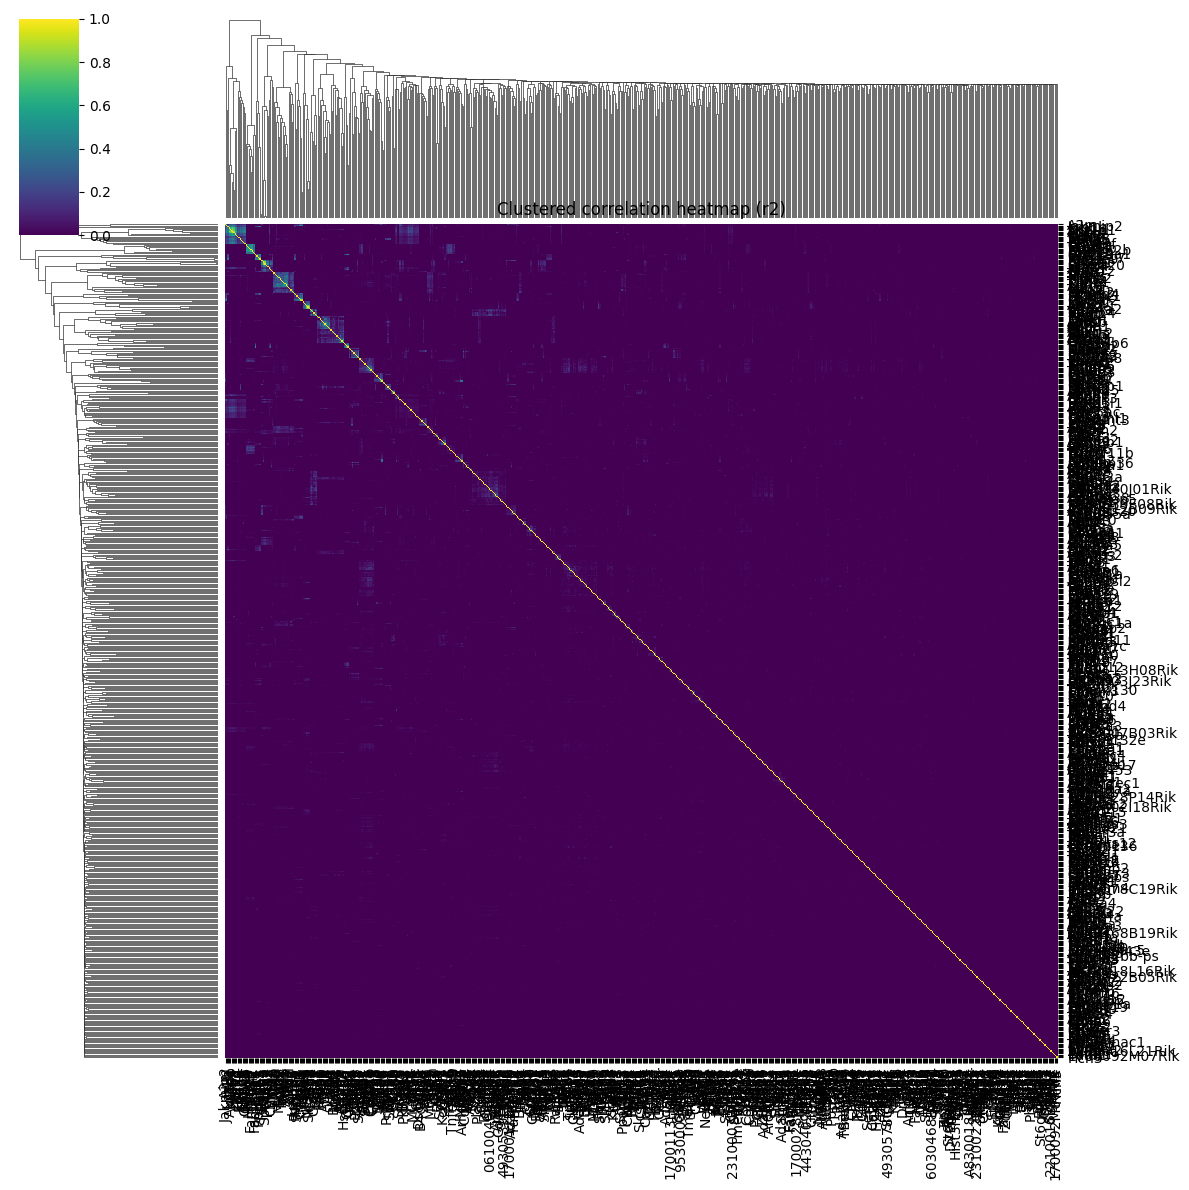

In [24]:
plot_corr_clustermap(mouse_corrs)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


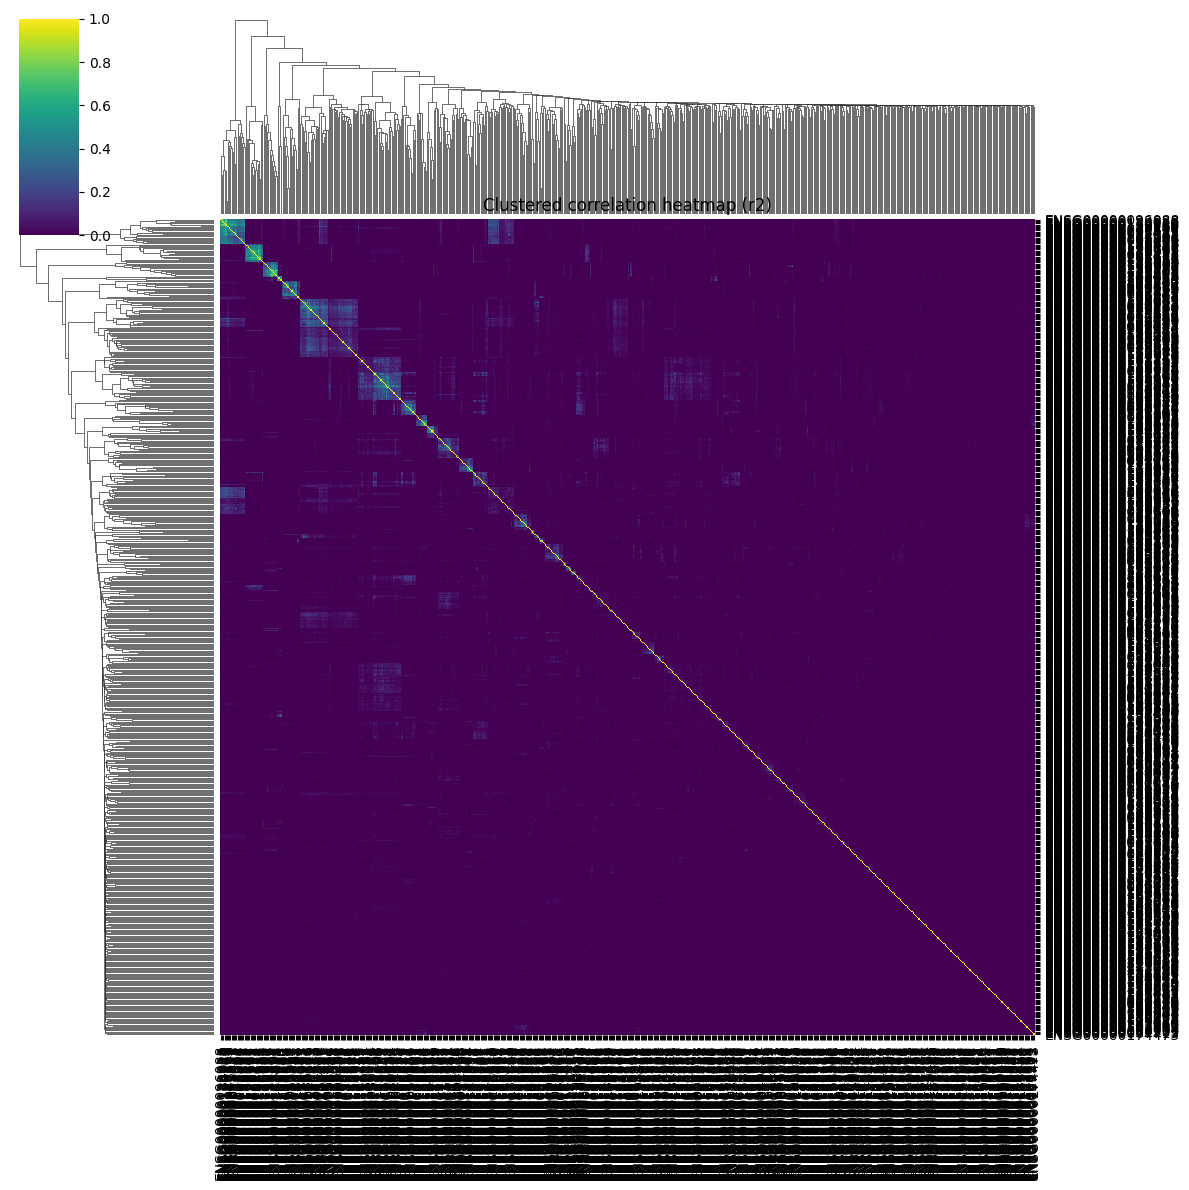

In [25]:
plot_corr_clustermap(human_ortholog_corr_df)

In [26]:
def plot_top_corr_subheatmaps(
    df,
    value_col="r2",
    *,
    max_panels=5,
    max_genes=50,
    min_genes=15,
    step=None,
    method="average",
    figsize_per_panel=(7, 6),
    verbose=False,
):
    """
    Plot up to `max_panels` clustered sub-heatmaps representing the most internally
    correlated local regions of the full clustered heatmap.

    Selection rule
    --------------
    1. Build a symmetric gene-gene matrix from columns ['g1', 'g2', value_col].
    2. Cluster genes globally using hierarchical clustering with distance = 1 - r2.
    3. Take the dendrogram leaf order.
    4. Slide windows of size up to `max_genes` along that order.
    5. Score each window by mean off-diagonal r2 within the window.
    6. Select the top-scoring non-overlapping windows, up to `max_panels`.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns 'g1', 'g2', and `value_col`.
    value_col : str
        Column to visualize, e.g. 'r2' or 'orth r2'.
    max_panels : int
        Maximum number of sub-heatmaps to generate.
    max_genes : int
        Maximum genes per sub-heatmap.
    min_genes : int
        Minimum genes per candidate window.
    step : int or None
        Window step size along clustered order. Default = max_genes // 4.
    method : str
        Linkage method for scipy.cluster.hierarchy.linkage.
    figsize_per_panel : tuple
        Base size for each panel; actual plotted size is 1.5x this.
    verbose : bool
        If True, print selected window info.

    Returns
    -------
    dict with:
        'matrix'          : full symmetric matrix
        'ordered_genes'   : clustered global leaf order
        'selected_windows': list of dicts with start, end, genes, score
        'figures'         : list of matplotlib figure objects
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import squareform

    if step is None:
        step = max(1, max_genes // 4)

    x = df[["g1", "g2", value_col]].dropna().copy()
    if x.empty:
        raise ValueError(f"No non-null values found in column {value_col!r}.")

    # Build symmetric matrix
    genes = pd.Index(sorted(set(x["g1"]).union(x["g2"])))
    mat = pd.DataFrame(np.nan, index=genes, columns=genes, dtype=float)

    for g1, g2, v in x.itertuples(index=False, name=None):
        mat.at[g1, g2] = float(v)
        mat.at[g2, g1] = float(v)

    np.fill_diagonal(mat.values, 1.0)
    mat = mat.fillna(0.0)

    # Global clustering using distance = 1 - r2
    dist = 1.0 - mat.values
    np.fill_diagonal(dist, 0.0)
    dist = np.clip(dist, 0.0, None)

    Z = linkage(squareform(dist, checks=False), method=method)
    order = leaves_list(Z)
    ordered_genes = mat.index[order]
    mat_ord = mat.loc[ordered_genes, ordered_genes]

    # Candidate windows along clustered order
    candidates = []
    n = len(ordered_genes)

    for start in range(0, n, step):
        end = min(start + max_genes, n)
        if end - start < min_genes:
            continue

        sub = mat_ord.iloc[start:end, start:end].values
        k = sub.shape[0]
        if k < 2:
            continue

        mask = ~np.eye(k, dtype=bool)
        vals = sub[mask]
        score = float(np.nanmean(vals))

        candidates.append(
            {
                "start": start,
                "end": end,
                "genes": list(ordered_genes[start:end]),
                "score": score,
            }
        )

    # Fallback if matrix is smaller than max_genes
    if not candidates and n >= 2:
        sub = mat_ord.values
        k = sub.shape[0]
        mask = ~np.eye(k, dtype=bool)
        candidates = [
            {
                "start": 0,
                "end": n,
                "genes": list(ordered_genes),
                "score": float(np.nanmean(sub[mask])),
            }
        ]

    # Select top non-overlapping windows
    candidates.sort(key=lambda d: d["score"], reverse=True)
    selected = []
    occupied = np.zeros(n, dtype=bool)

    for cand in candidates:
        s, e = cand["start"], cand["end"]
        if occupied[s:e].any():
            continue
        selected.append(cand)
        occupied[s:e] = True
        if len(selected) >= max_panels:
            break

    if verbose:
        for i, win in enumerate(selected, start=1):
            print(
                f"Panel {i}: genes {win['start']}:{win['end']}, "
                f"n={len(win['genes'])}, score={win['score']:.3f}"
            )

    # Plot each selected window
    figs = []
    for i, win in enumerate(selected, start=1):
        sub = mat_ord.loc[win["genes"], win["genes"]]

        fig, ax = plt.subplots(
            figsize=(figsize_per_panel[0] * 1.5, figsize_per_panel[1] * 1.5)
        )

        sns.heatmap(
            sub,
            ax=ax,
            cmap="viridis",
            square=True,
            xticklabels=True,
            yticklabels=True,
        )

        # Force all gene labels to display
        ax.set_xticks(np.arange(len(sub.columns)) + 0.5)
        ax.set_yticks(np.arange(len(sub.index)) + 0.5)
        ax.set_xticklabels(sub.columns, rotation=90, fontsize=8)
        ax.set_yticklabels(sub.index, rotation=0, fontsize=8)

        ax.set_title(
            f"{value_col} block {i}: n={len(win['genes'])}, mean={win['score']:.3f}"
        )
        ax.set_xlabel("")
        ax.set_ylabel("")

        plt.tight_layout()
        figs.append(fig)

    return {
        "matrix": mat,
        "ordered_genes": list(ordered_genes),
        "selected_windows": selected,
        "figures": figs,
    }

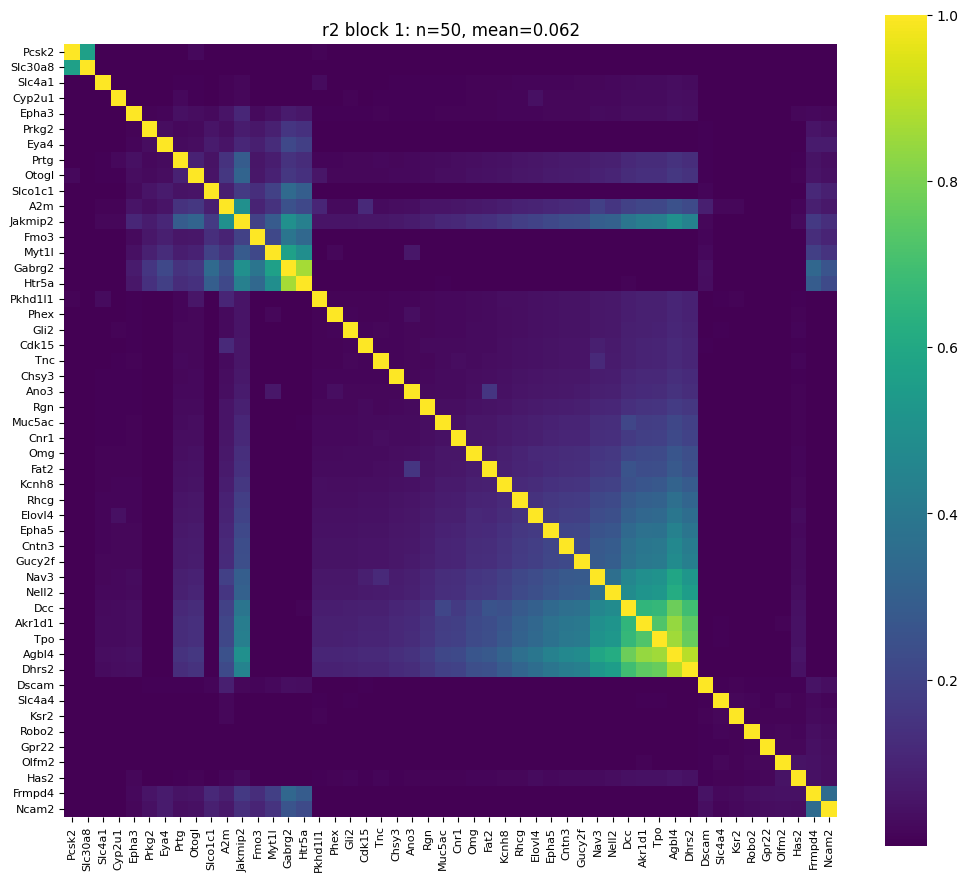

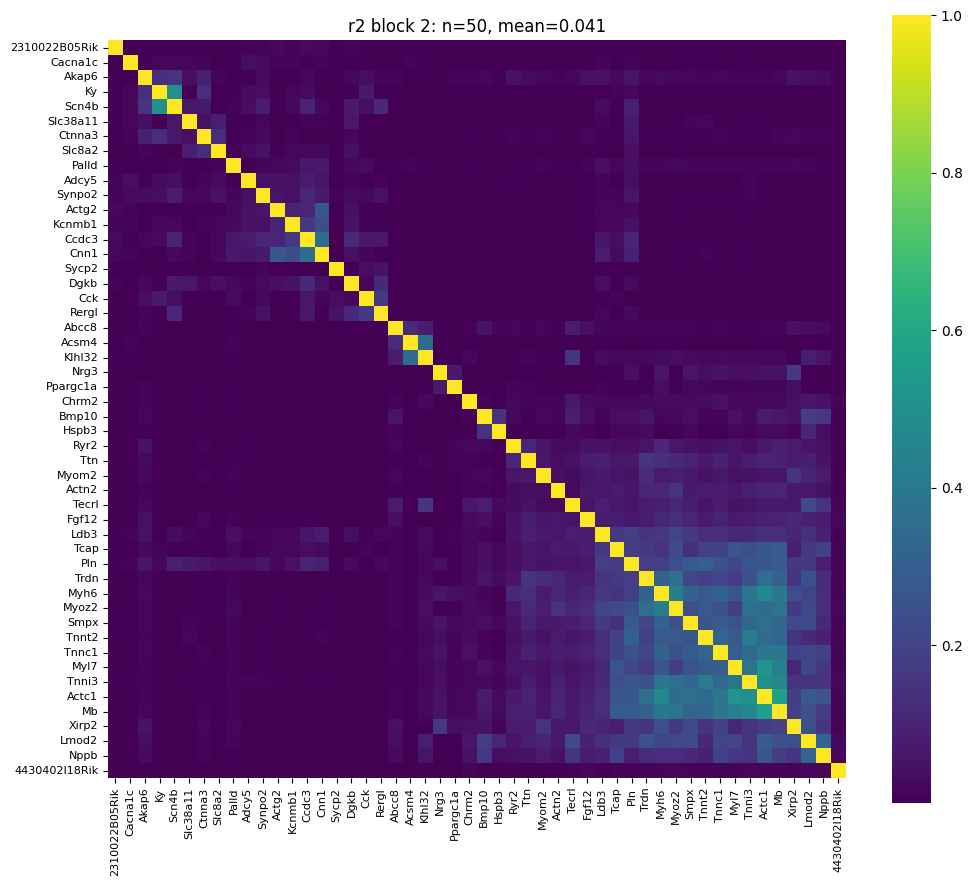

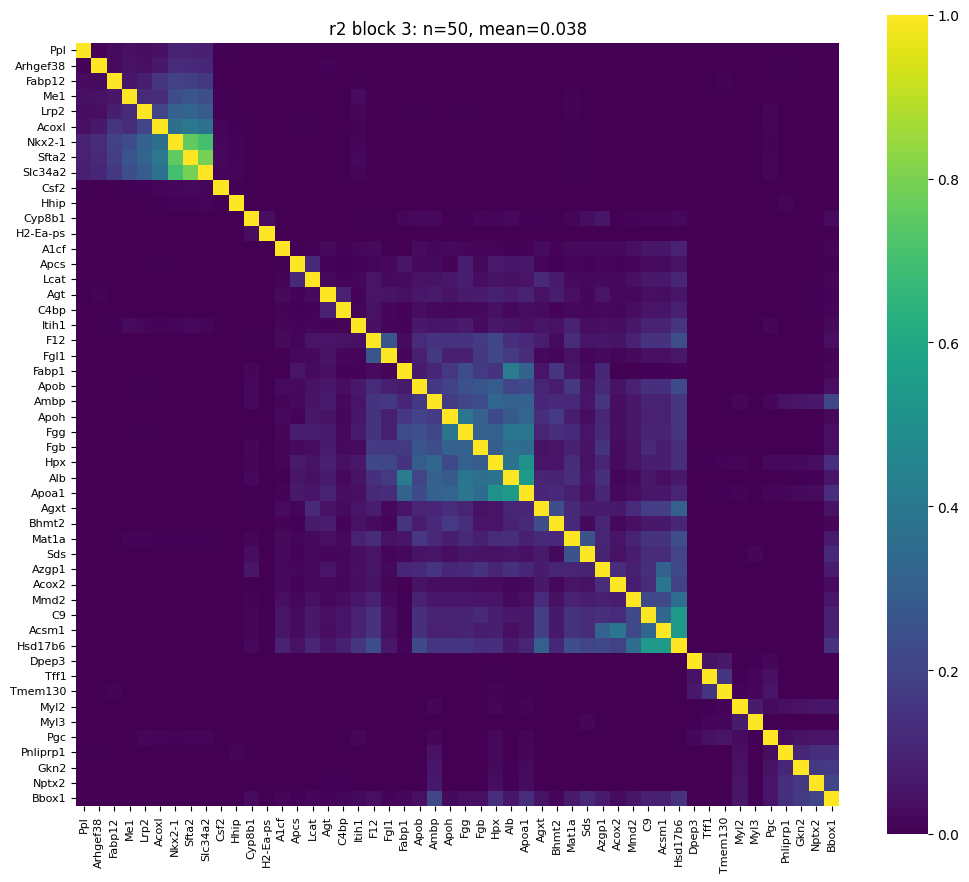

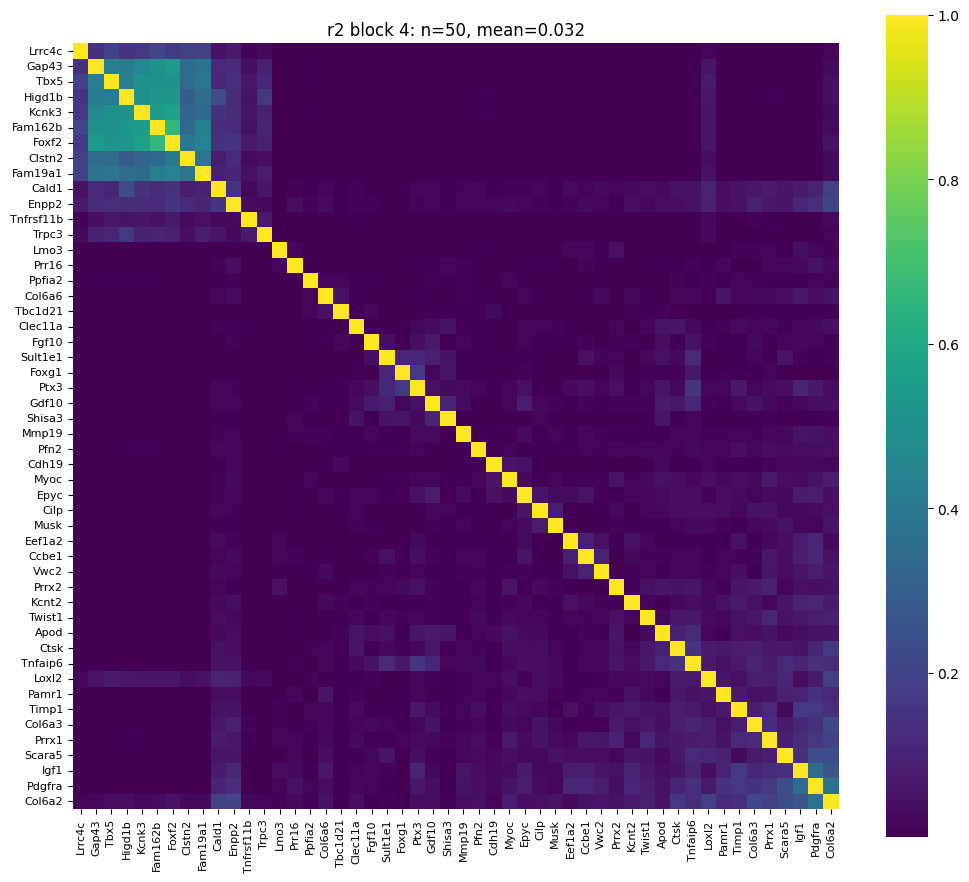

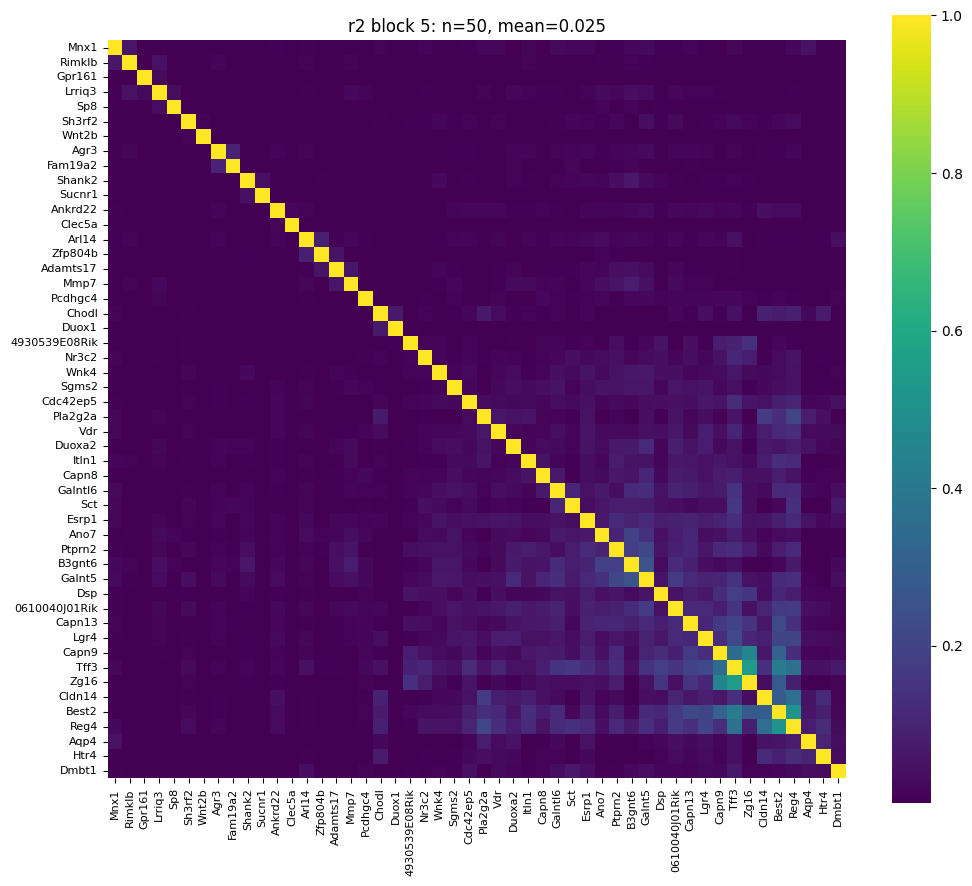

In [27]:
res = plot_top_corr_subheatmaps(mouse_corrs, value_col="r2", verbose=False)

In [28]:
# Last plot with Spink4, Reg4, etc is specific to cells in the small intestine (goblet cells)

### Repeating with human

In [29]:
def plot_human_corr_subheatmaps_with_mouse_names(
    human_ortholog_corr_df,
    ortholog_df,
    *,
    value_col="r2",
    max_panels=5,
    max_genes=50,
    min_genes=15,
    step=None,
    method="average",
    figsize_per_panel=(7, 6),
    verbose=False,
):
    """
    Plot up to `max_panels` clustered human-gene correlation sub-heatmaps, but label
    the axes with the orthologous mouse gene names instead of human Ensembl IDs.

    Inputs
    ------
    human_ortholog_corr_df : pd.DataFrame
        Must contain columns:
          - 'g1', 'g2' : human Ensembl IDs
          - `value_col`: correlation-like value (usually 'r2' or 'orth r2')
    ortholog_df : pd.DataFrame
        Output of `mouse_human_orthologs_biomart`, expected to contain:
          - 'human_ensembl_id'
          - 'mouse_gene_name'

    Selection rule
    --------------
    1. Build a symmetric human gene-gene matrix from ['g1', 'g2', value_col].
    2. Cluster genes globally using hierarchical clustering with distance = 1 - value.
    3. Take the dendrogram leaf order.
    4. Slide windows of size up to `max_genes` along that order.
    5. Score each window by mean off-diagonal value within the window.
    6. Select the top-scoring non-overlapping windows, up to `max_panels`.
    7. Plot each selected window, replacing human Ensembl IDs on the axes with the
       orthologous mouse gene names.

    Notes
    -----
    - If multiple human genes map to the same mouse name, labels are made unique by
      appending '|<human_ensembl_id>'.
    - If a human Ensembl ID is not found in `ortholog_df`, the human Ensembl ID is used.
    - Figure size is 1.5x `figsize_per_panel`, and all labels are forced to display.

    Returns
    -------
    dict with:
        'matrix'          : full symmetric matrix using human Ensembl IDs
        'ordered_genes'   : clustered human Ensembl ID order
        'selected_windows': list of dicts with start, end, genes, labels, score
        'figures'         : list of matplotlib figure objects
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import squareform

    if step is None:
        step = max(1, max_genes // 4)

    req_df = {"g1", "g2", value_col}
    missing_df = req_df - set(human_ortholog_corr_df.columns)
    if missing_df:
        raise KeyError(f"human_ortholog_corr_df missing required columns: {sorted(missing_df)}")

    req_ortho = {"human_ensembl_id", "mouse_gene_name"}
    missing_ortho = req_ortho - set(ortholog_df.columns)
    if missing_ortho:
        raise KeyError(f"ortholog_df missing required columns: {sorted(missing_ortho)}")

    x = human_ortholog_corr_df[["g1", "g2", value_col]].dropna().copy()
    if x.empty:
        raise ValueError(f"No non-null values found in column {value_col!r}.")

    # Human Ensembl -> mouse ortholog name mapping
    ortho = ortholog_df[["human_ensembl_id", "mouse_gene_name"]].copy()
    ortho["human_ensembl_id"] = ortho["human_ensembl_id"].astype(str)
    ortho["mouse_gene_name"] = ortho["mouse_gene_name"].astype(str)

    # Keep first mapping per human Ensembl ID
    ortho = ortho.drop_duplicates(subset=["human_ensembl_id"], keep="first")
    base_map = dict(zip(ortho["human_ensembl_id"], ortho["mouse_gene_name"]))

    # Build symmetric matrix on human Ensembl IDs
    genes = pd.Index(sorted(set(x["g1"]).union(x["g2"])))
    mat = pd.DataFrame(np.nan, index=genes, columns=genes, dtype=float)

    for g1, g2, v in x.itertuples(index=False, name=None):
        mat.at[g1, g2] = float(v)
        mat.at[g2, g1] = float(v)

    np.fill_diagonal(mat.values, 1.0)
    mat = mat.fillna(0.0)

    # Cluster globally using distance = 1 - correlation-like value
    dist = 1.0 - mat.values
    np.fill_diagonal(dist, 0.0)
    dist = np.clip(dist, 0.0, None)

    Z = linkage(squareform(dist, checks=False), method=method)
    order = leaves_list(Z)
    ordered_genes = list(mat.index[order])
    mat_ord = mat.loc[ordered_genes, ordered_genes]

    # Candidate windows along clustered order
    candidates = []
    n = len(ordered_genes)

    for start in range(0, n, step):
        end = min(start + max_genes, n)
        if end - start < min_genes:
            continue

        sub = mat_ord.iloc[start:end, start:end].values
        k = sub.shape[0]
        if k < 2:
            continue

        mask = ~np.eye(k, dtype=bool)
        score = float(np.nanmean(sub[mask]))

        candidates.append(
            {
                "start": start,
                "end": end,
                "genes": ordered_genes[start:end],
                "score": score,
            }
        )

    if not candidates and n >= 2:
        sub = mat_ord.values
        mask = ~np.eye(sub.shape[0], dtype=bool)
        candidates = [
            {
                "start": 0,
                "end": n,
                "genes": ordered_genes,
                "score": float(np.nanmean(sub[mask])),
            }
        ]

    # Select top non-overlapping windows
    candidates.sort(key=lambda d: d["score"], reverse=True)
    selected = []
    occupied = np.zeros(n, dtype=bool)

    for cand in candidates:
        s, e = cand["start"], cand["end"]
        if occupied[s:e].any():
            continue
        selected.append(cand)
        occupied[s:e] = True
        if len(selected) >= max_panels:
            break

    # Make per-window labels unique, using mouse names where possible
    def make_window_labels(human_ids):
        raw = []
        for hid in human_ids:
            nm = base_map.get(str(hid), str(hid))
            if not nm or str(nm).strip().lower() == "nan":
                nm = str(hid)
            raw.append(str(nm))

        counts = pd.Series(raw).value_counts()
        labels = []
        for hid, nm in zip(human_ids, raw):
            labels.append(f"{nm}|{hid}" if counts[nm] > 1 else nm)
        return labels

    if verbose:
        for i, win in enumerate(selected, start=1):
            print(
                f"Panel {i}: genes {win['start']}:{win['end']}, "
                f"n={len(win['genes'])}, score={win['score']:.3f}"
            )

    # Plot
    figs = []
    for i, win in enumerate(selected, start=1):
        sub = mat_ord.loc[win["genes"], win["genes"]].copy()
        labels = make_window_labels(win["genes"])
        sub.index = labels
        sub.columns = labels
        win["labels"] = labels

        fig, ax = plt.subplots(
            figsize=(figsize_per_panel[0] * 1.5, figsize_per_panel[1] * 1.5)
        )

        sns.heatmap(
            sub,
            ax=ax,
            cmap="viridis",
            square=True,
            xticklabels=True,
            yticklabels=True,
        )

        # Force all labels to display
        ax.set_xticks(np.arange(len(sub.columns)) + 0.5)
        ax.set_yticks(np.arange(len(sub.index)) + 0.5)
        ax.set_xticklabels(sub.columns, rotation=90, fontsize=8)
        ax.set_yticklabels(sub.index, rotation=0, fontsize=8)

        ax.set_title(
            f"{value_col} block {i}: n={len(win['genes'])}, mean={win['score']:.3f}"
        )
        ax.set_xlabel("")
        ax.set_ylabel("")
        plt.tight_layout()
        figs.append(fig)

    return {
        "matrix": mat,
        "ordered_genes": ordered_genes,
        "selected_windows": selected,
        "figures": figs,
    }

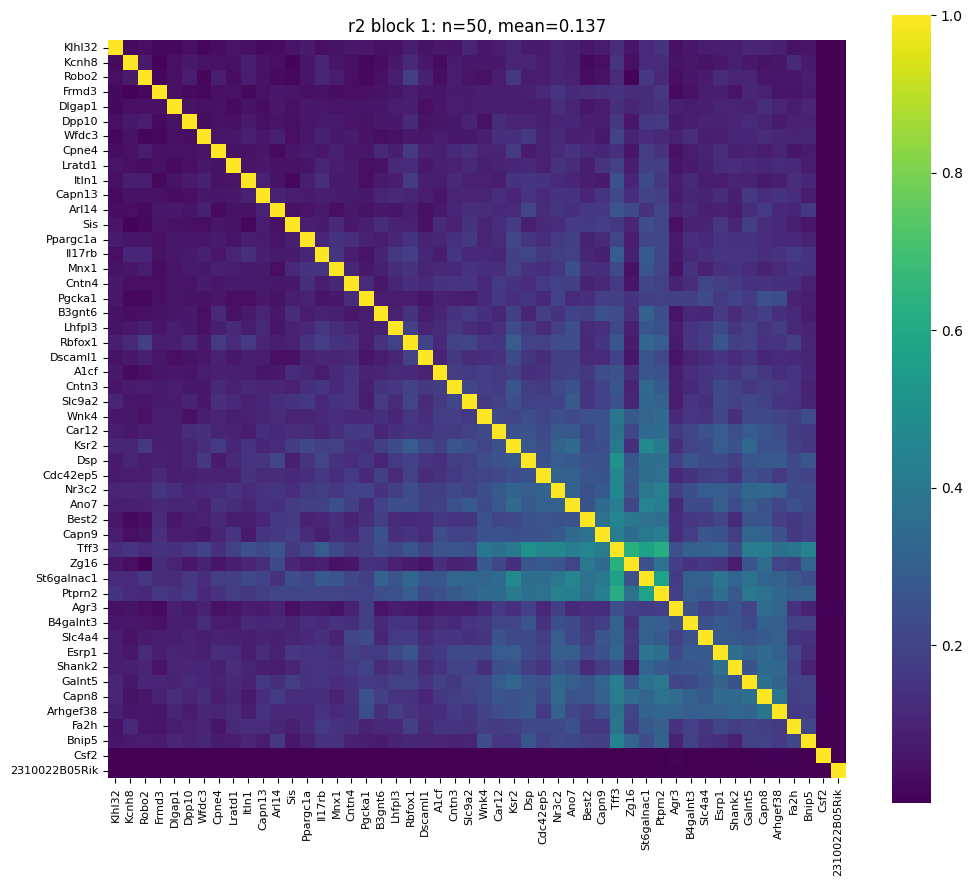

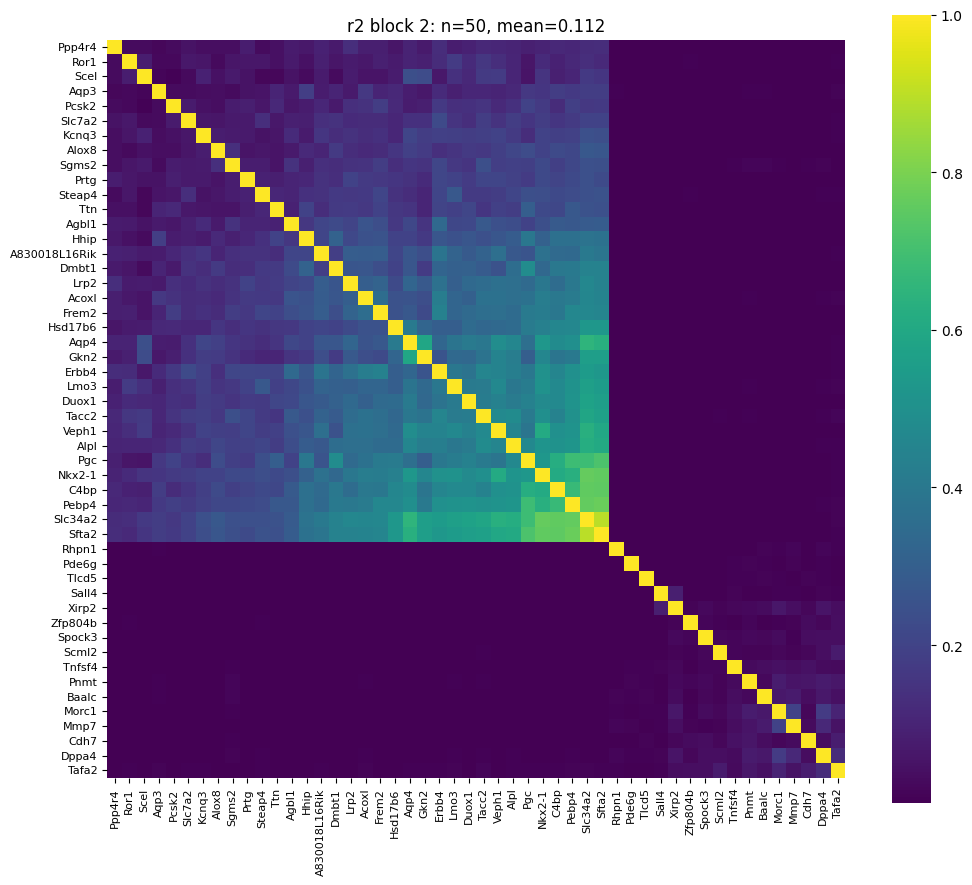

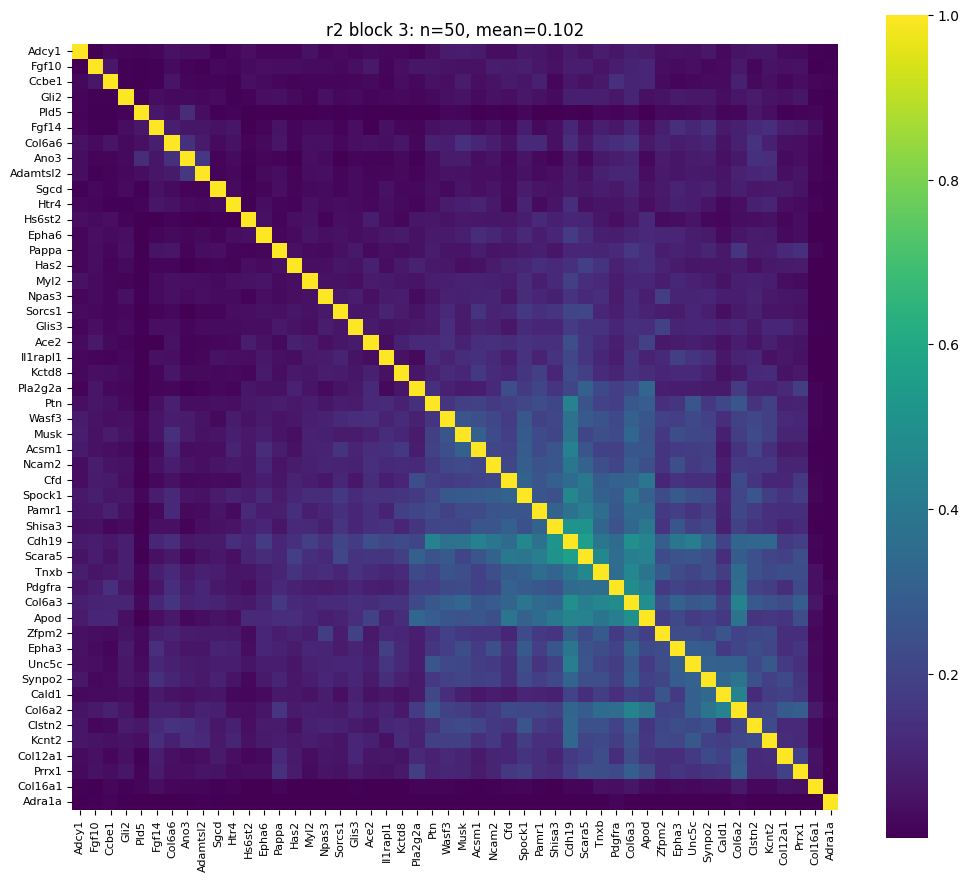

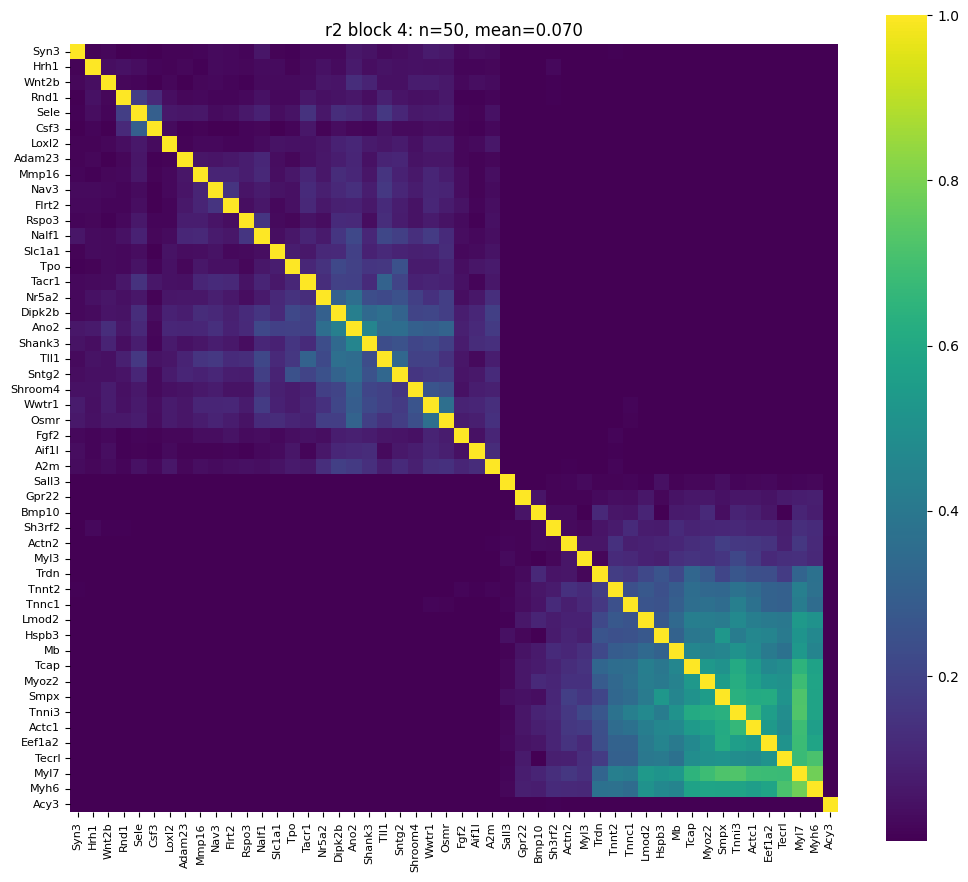

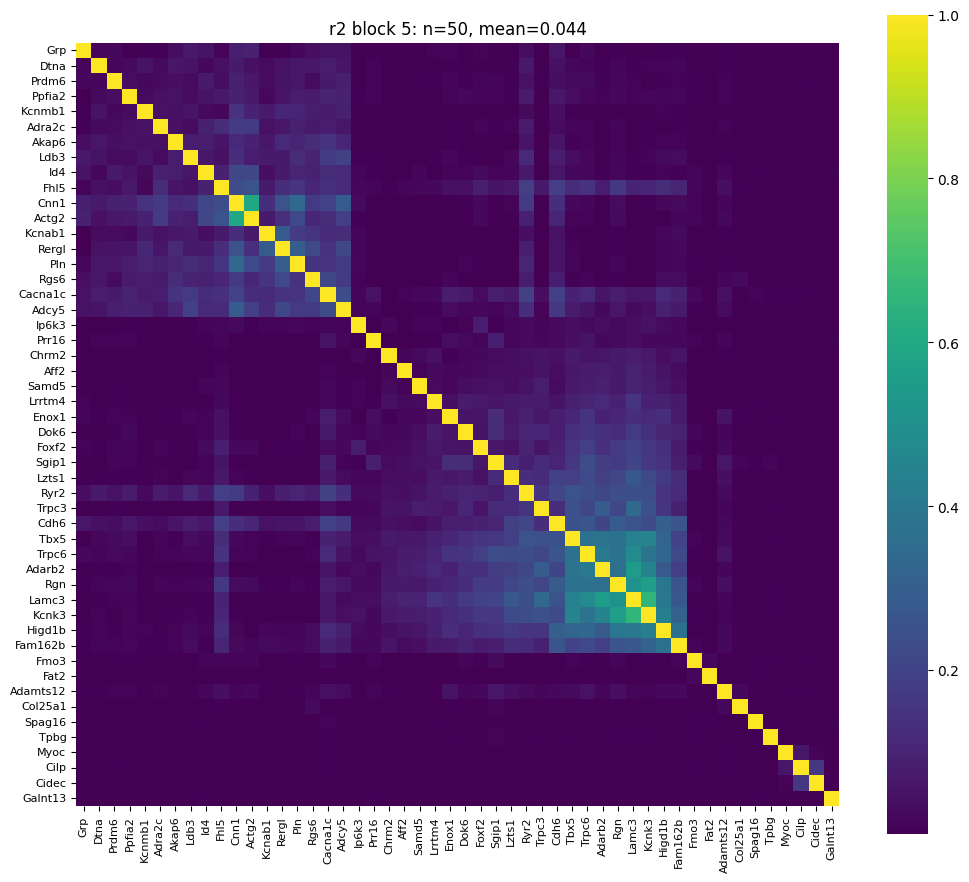

In [30]:
res = plot_human_corr_subheatmaps_with_mouse_names(
    human_ortholog_corr_df,
    ortholog_df,
    value_col="r2",
    max_panels=5,
    max_genes=50,
    verbose=False,
)

### Mouse and human side-by-side

In [74]:
def plot_paired_human_mouse_top_corr_subheatmaps(
    human_corrs_df,
    mouse_corrs_df,
    ortholog_df,
    *,
    human_value_col="r2",
    mouse_value_col="r2",
    max_panels=5,
    max_genes=50,
    min_genes=15,
    avg_corr_threshold=0.0,
    step=None,
    method="average",
    figsize_per_panel=(12, 6),
    human_title="Human",
    mouse_title="Mouse",
    verbose=False,
):
    """
    Plot paired human/mouse sub-heatmaps side by side.

    Human windows are selected by clustering the human correlation matrix, where
    human_corrs_df['g1'] and ['g2'] are human Ensembl IDs. Axes for BOTH the human
    and mouse panels are labeled with the orthologous mouse gene names from ortholog_df.

    After a candidate human window is selected, genes are trimmed so that only genes
    whose average within-window correlation to the other genes is >= avg_corr_threshold
    are kept.

    Returns
    -------
    dict with:
        'human_matrix'     : full human symmetric matrix (indexed by human Ensembl IDs)
        'mouse_matrix'     : full mouse symmetric matrix (indexed by mouse gene names)
        'ordered_genes'    : clustered global human Ensembl leaf order
        'selected_windows' : selected human windows
        'figures'          : list of matplotlib figure objects
        'modules_human'    : list of human Ensembl-ID modules
        'modules_mouse'    : list of corresponding mouse-name modules
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import squareform

    if step is None:
        step = max(1, max_genes // 4)

    def build_symmetric_matrix(df, value_col):
        req = {"g1", "g2", value_col}
        missing = req - set(df.columns)
        if missing:
            raise KeyError(f"Missing required columns for {value_col!r}: {sorted(missing)}")

        x = df[["g1", "g2", value_col]].dropna().copy()
        if x.empty:
            raise ValueError(f"No non-null values found in column {value_col!r}.")

        x["g1"] = x["g1"].astype(str)
        x["g2"] = x["g2"].astype(str)

        genes = pd.Index(sorted(set(x["g1"]).union(x["g2"])))
        mat = pd.DataFrame(np.nan, index=genes, columns=genes, dtype=float)

        for g1, g2, v in x.itertuples(index=False, name=None):
            mat.at[g1, g2] = float(v)
            mat.at[g2, g1] = float(v)

        np.fill_diagonal(mat.values, 1.0)
        return mat.fillna(0.0)

    def trim_genes_by_avg_corr(sub_df, threshold):
        if sub_df.shape[0] < 2:
            return list(sub_df.index)

        vals = sub_df.values.astype(float)
        n = vals.shape[0]
        off_diag_sum = vals.sum(axis=1) - np.diag(vals)
        avg_off_diag = off_diag_sum / max(n - 1, 1)
        keep_mask = avg_off_diag >= threshold
        return list(sub_df.index[keep_mask])

    def mean_offdiag(sub_df):
        vals = np.asarray(sub_df, dtype=float)
        n = vals.shape[0]
        if n < 2:
            return np.nan
        mask = ~np.eye(n, dtype=bool)
        return float(np.nanmean(vals[mask]))

    req_ortho = {"human_ensembl_id", "mouse_gene_name"}
    missing_ortho = req_ortho - set(ortholog_df.columns)
    if missing_ortho:
        raise KeyError(f"ortholog_df missing required columns: {sorted(missing_ortho)}")

    ortho = ortholog_df[["human_ensembl_id", "mouse_gene_name"]].copy()
    ortho["human_ensembl_id"] = ortho["human_ensembl_id"].astype(str)
    ortho["mouse_gene_name"] = ortho["mouse_gene_name"].astype(str)
    ortho = ortho.drop_duplicates(subset=["human_ensembl_id"], keep="first")
    human_to_mouse_name = dict(zip(ortho["human_ensembl_id"], ortho["mouse_gene_name"]))

    human_mat = build_symmetric_matrix(human_corrs_df, human_value_col)
    mouse_mat = build_symmetric_matrix(mouse_corrs_df, mouse_value_col)

    dist = 1.0 - human_mat.values
    np.fill_diagonal(dist, 0.0)
    dist = np.clip(dist, 0.0, None)

    Z = linkage(squareform(dist, checks=False), method=method)
    order = leaves_list(Z)
    ordered_genes = list(human_mat.index[order])
    human_mat_ord = human_mat.loc[ordered_genes, ordered_genes]

    candidates = []
    n = len(ordered_genes)

    for start in range(0, n, step):
        end = min(start + max_genes, n)
        if end - start < min_genes:
            continue

        sub = human_mat_ord.iloc[start:end, start:end].values
        if sub.shape[0] < 2:
            continue

        mask = ~np.eye(sub.shape[0], dtype=bool)
        score = float(np.nanmean(sub[mask]))

        candidates.append(
            {
                "start": start,
                "end": end,
                "genes": ordered_genes[start:end],
                "score": score,
            }
        )

    if not candidates and n >= 2:
        sub = human_mat_ord.values
        mask = ~np.eye(sub.shape[0], dtype=bool)
        candidates = [
            {
                "start": 0,
                "end": n,
                "genes": ordered_genes,
                "score": float(np.nanmean(sub[mask])),
            }
        ]

    candidates.sort(key=lambda d: d["score"], reverse=True)
    selected = []
    occupied = np.zeros(n, dtype=bool)

    for cand in candidates:
        s, e = cand["start"], cand["end"]
        if occupied[s:e].any():
            continue

        cand_sub = human_mat_ord.loc[cand["genes"], cand["genes"]]
        trimmed_genes = trim_genes_by_avg_corr(cand_sub, avg_corr_threshold)

        if len(trimmed_genes) < 2:
            continue

        trimmed_sub = human_mat_ord.loc[trimmed_genes, trimmed_genes]
        trimmed_score = mean_offdiag(trimmed_sub)

        selected.append(
            {
                "start": s,
                "end": e,
                "genes": trimmed_genes,
                "score": trimmed_score,
                "n_genes": len(trimmed_genes),
            }
        )

        occupied[s:e] = True
        if len(selected) >= max_panels:
            break

    def make_window_label_info(human_ids):
        raw_mouse_names = []
        for hid in human_ids:
            nm = human_to_mouse_name.get(str(hid), str(hid))
            if not nm or str(nm).strip().lower() == "nan":
                nm = str(hid)
            raw_mouse_names.append(str(nm))

        counts = pd.Series(raw_mouse_names).value_counts()
        display_labels = []
        for hid, nm in zip(human_ids, raw_mouse_names):
            display_labels.append(f"{nm}|{hid}" if counts[nm] > 1 else nm)

        return raw_mouse_names, display_labels

    figs = []
    module_genes_human = []
    module_genes_mouse = []

    for i, win in enumerate(selected, start=1):
        human_ids = list(win["genes"])
        raw_mouse_names, display_labels = make_window_label_info(human_ids)

        module_genes_human.append(list(human_ids))
        module_genes_mouse.append(list(raw_mouse_names))

        hsub = human_mat.loc[human_ids, human_ids].copy()
        hsub.index = display_labels
        hsub.columns = display_labels
        h_mean = mean_offdiag(hsub)

        msub = mouse_mat.reindex(index=raw_mouse_names, columns=raw_mouse_names).copy()
        msub = msub.fillna(0.0)

        for g in raw_mouse_names:
            if g in mouse_mat.index:
                msub.at[g, g] = 1.0

        msub.index = display_labels
        msub.columns = display_labels
        m_mean = mean_offdiag(msub)

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(figsize_per_panel[0] * 1.5, figsize_per_panel[1] * 1.5),
            constrained_layout=True,
        )

        panels = [
            (axes[0], hsub, f"{human_title} {human_value_col} block {i}\nmean off-diag = {h_mean:.3f}"),
            (axes[1], msub, f"{mouse_title} {mouse_value_col} block {i}\nmean off-diag = {m_mean:.3f}"),
        ]

        for ax, sub, title in panels:
            sns.heatmap(
                sub,
                ax=ax,
                cmap="viridis",
                square=True,
                xticklabels=True,
                yticklabels=True,
                cbar=True,
            )

            ax.set_xticks(np.arange(len(sub.columns)) + 0.5)
            ax.set_yticks(np.arange(len(sub.index)) + 0.5)
            ax.set_xticklabels(sub.columns, rotation=90, fontsize=8)
            ax.set_yticklabels(sub.index, rotation=0, fontsize=8)
            ax.set_title(title)
            ax.set_xlabel("")
            ax.set_ylabel("")

        figs.append(fig)

    return {
        "human_matrix": human_mat,
        "mouse_matrix": mouse_mat,
        "ordered_genes": ordered_genes,
        "selected_windows": selected,
        "figures": figs,
        "modules_human": module_genes_human,
        "modules_mouse": module_genes_mouse,
    }

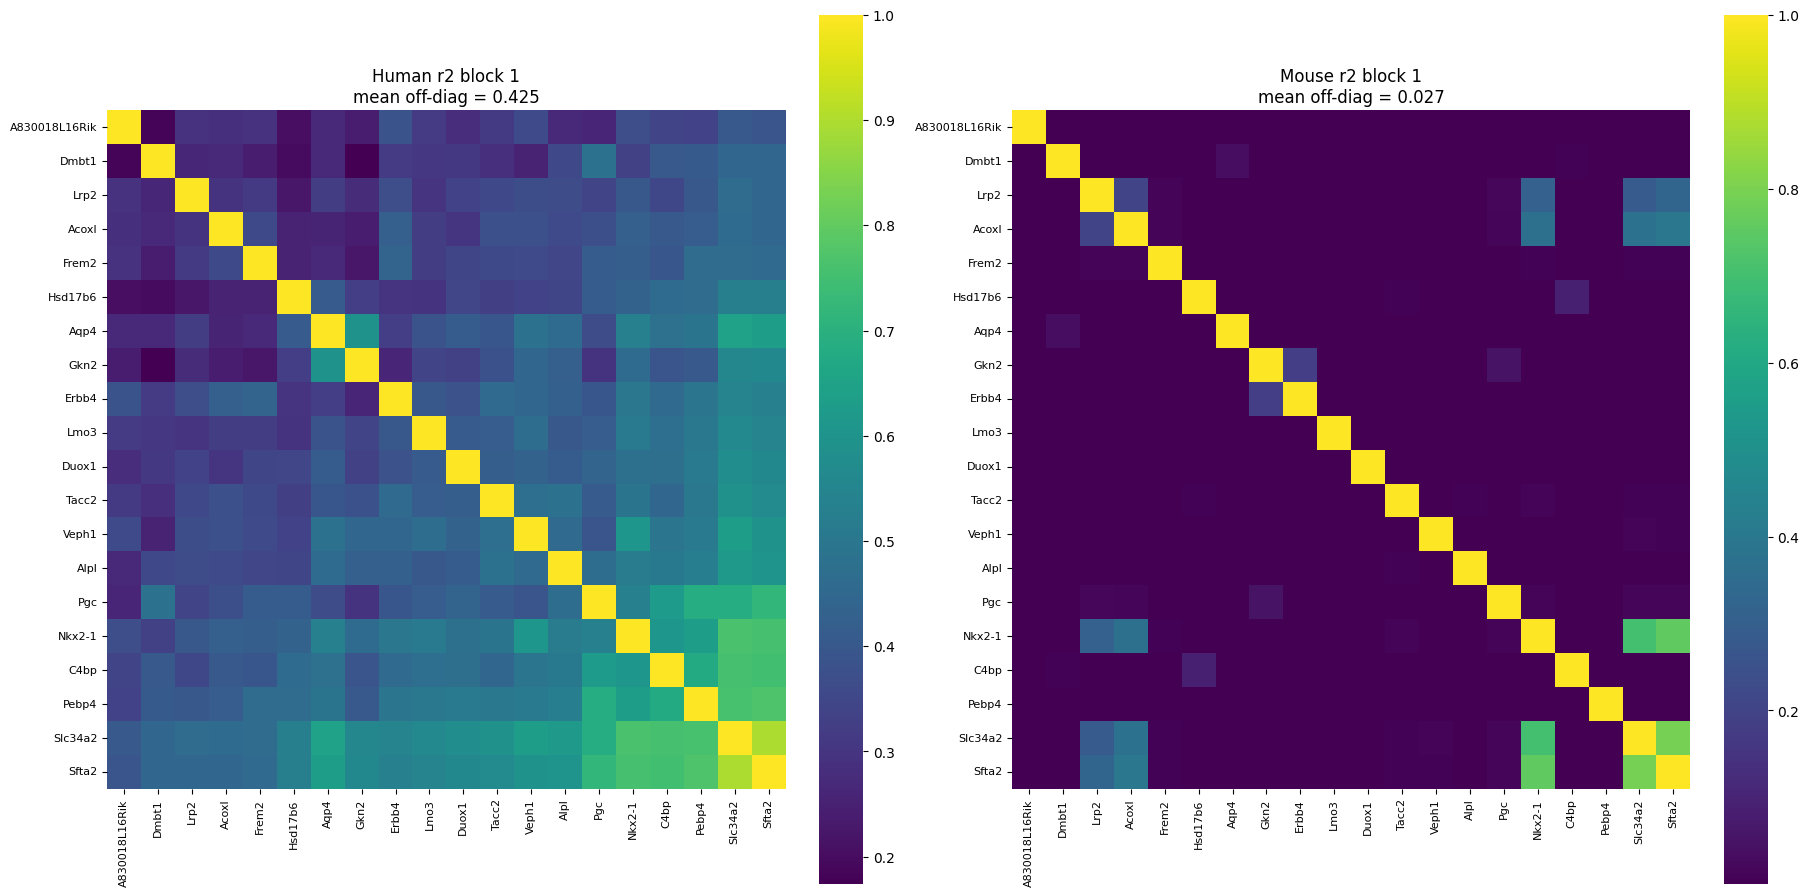

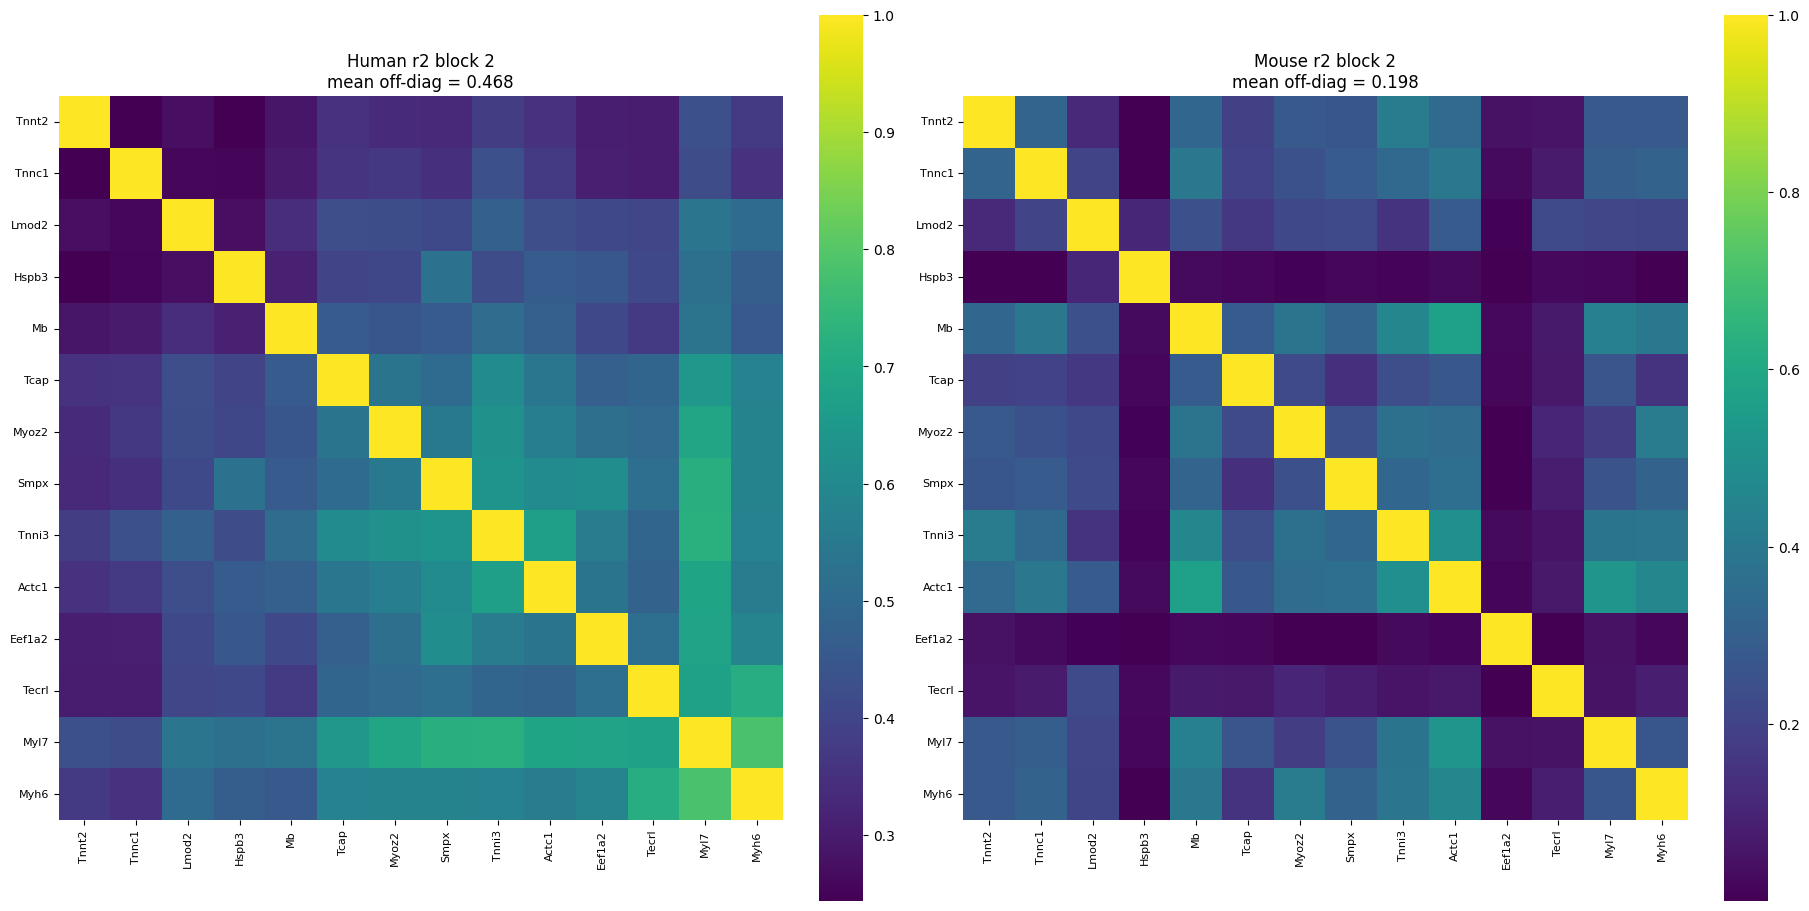

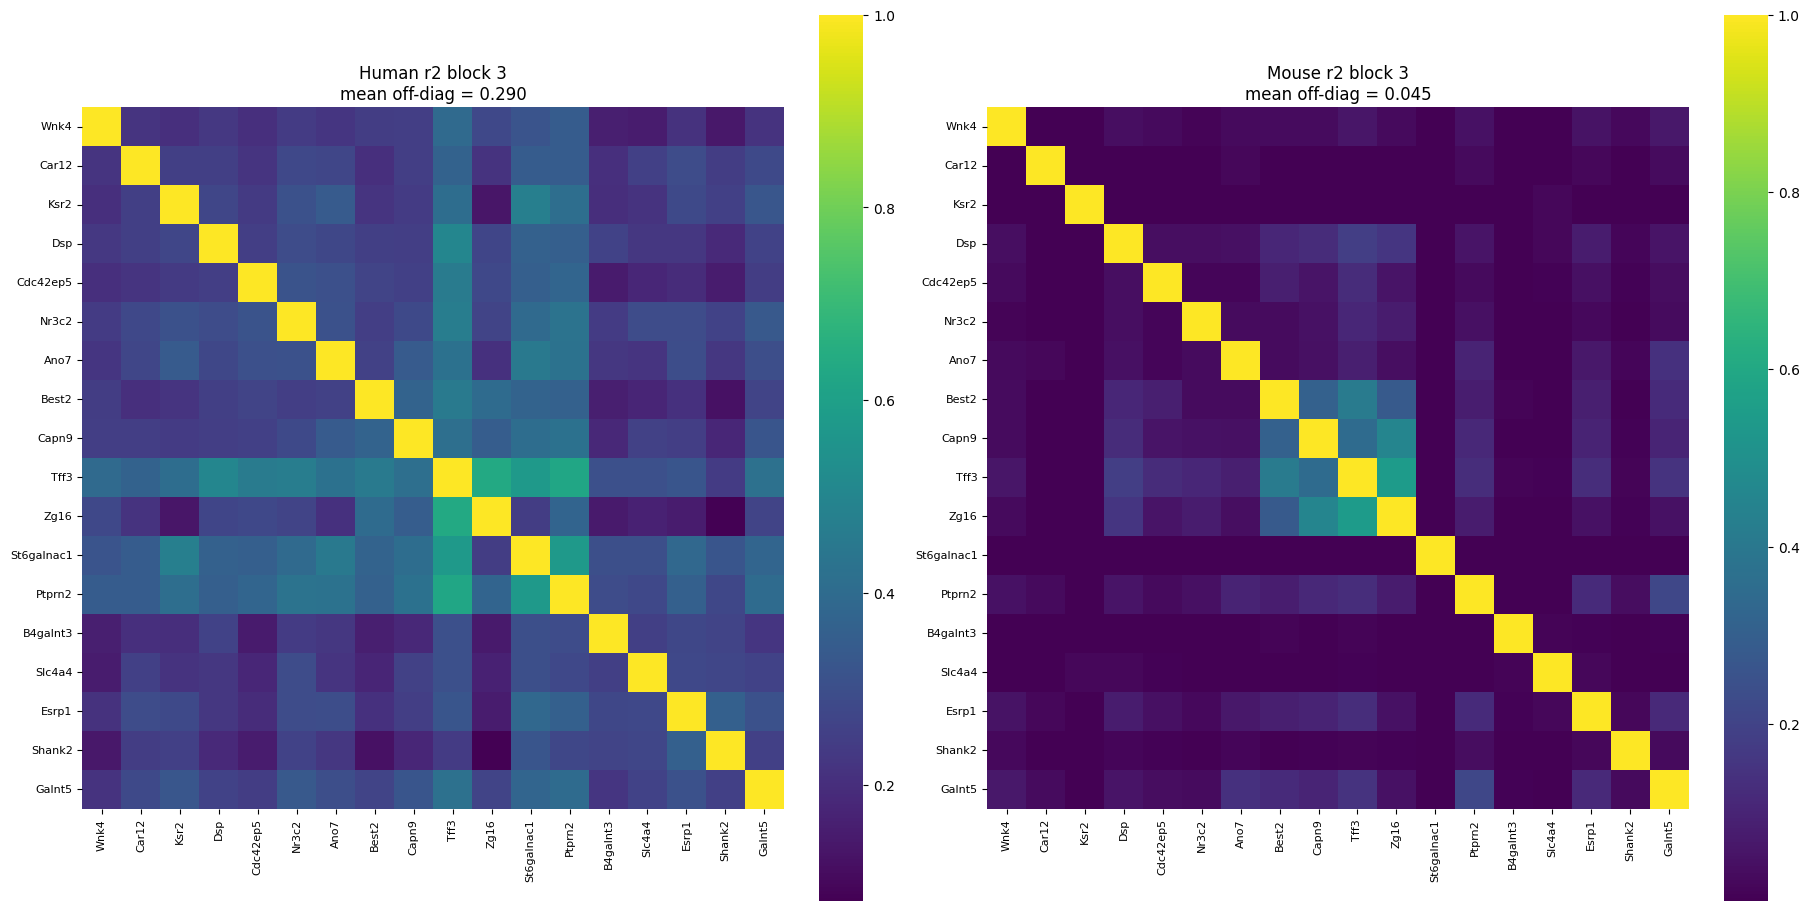

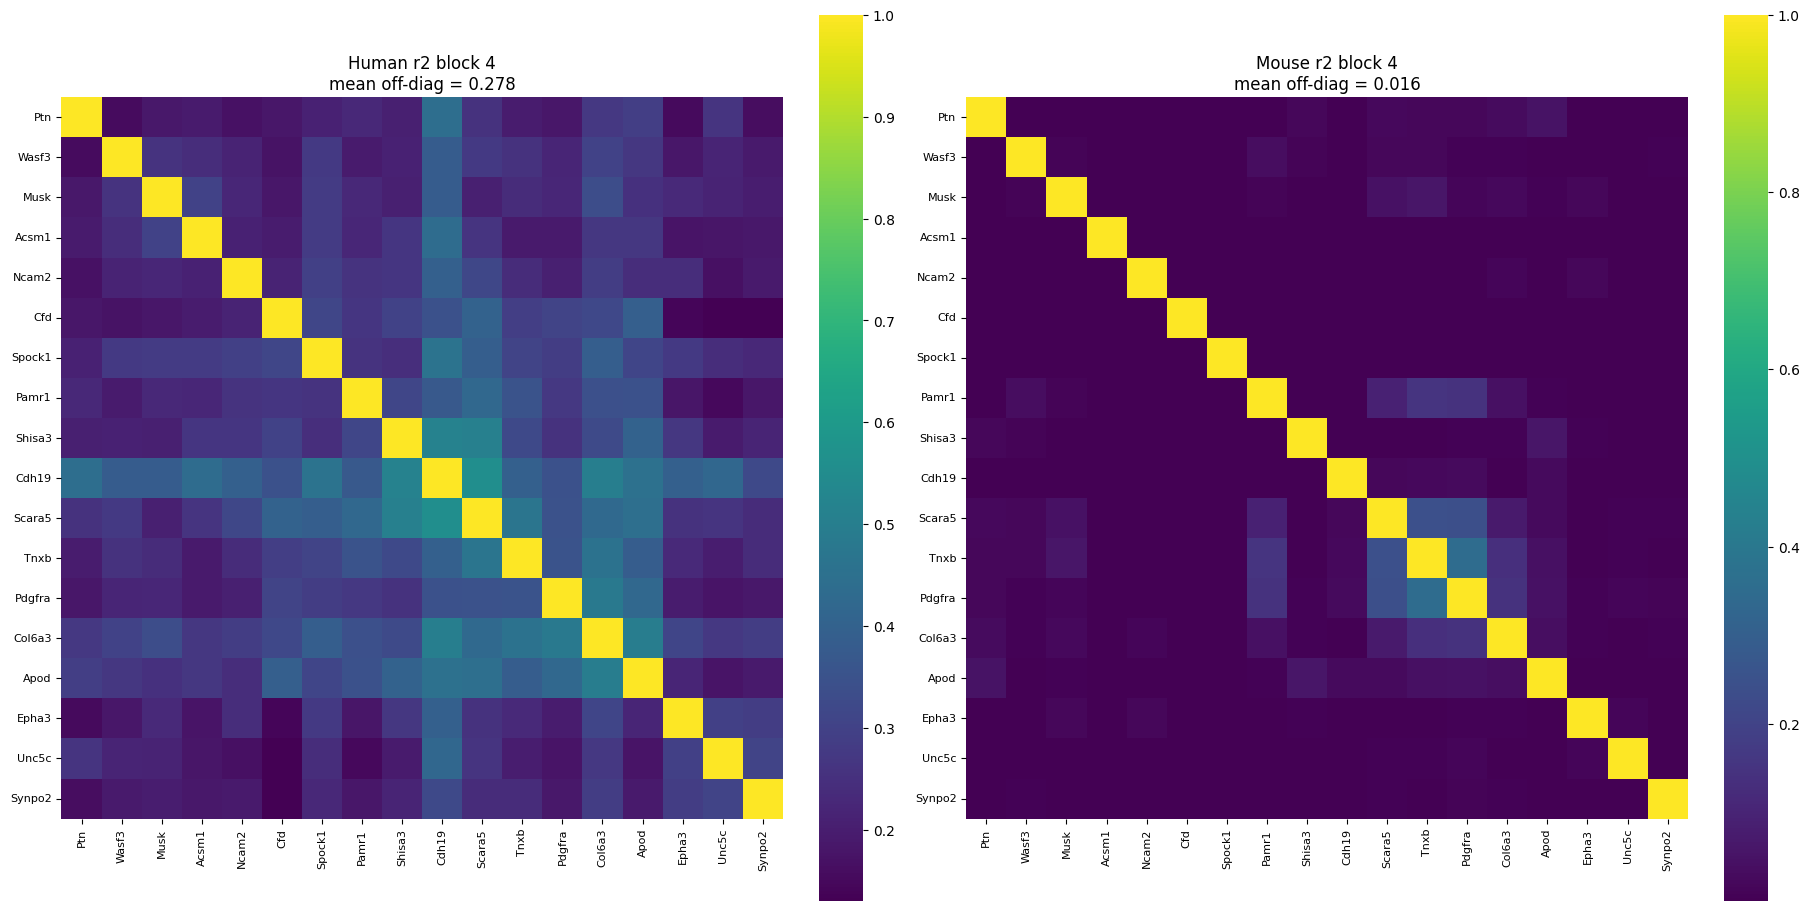

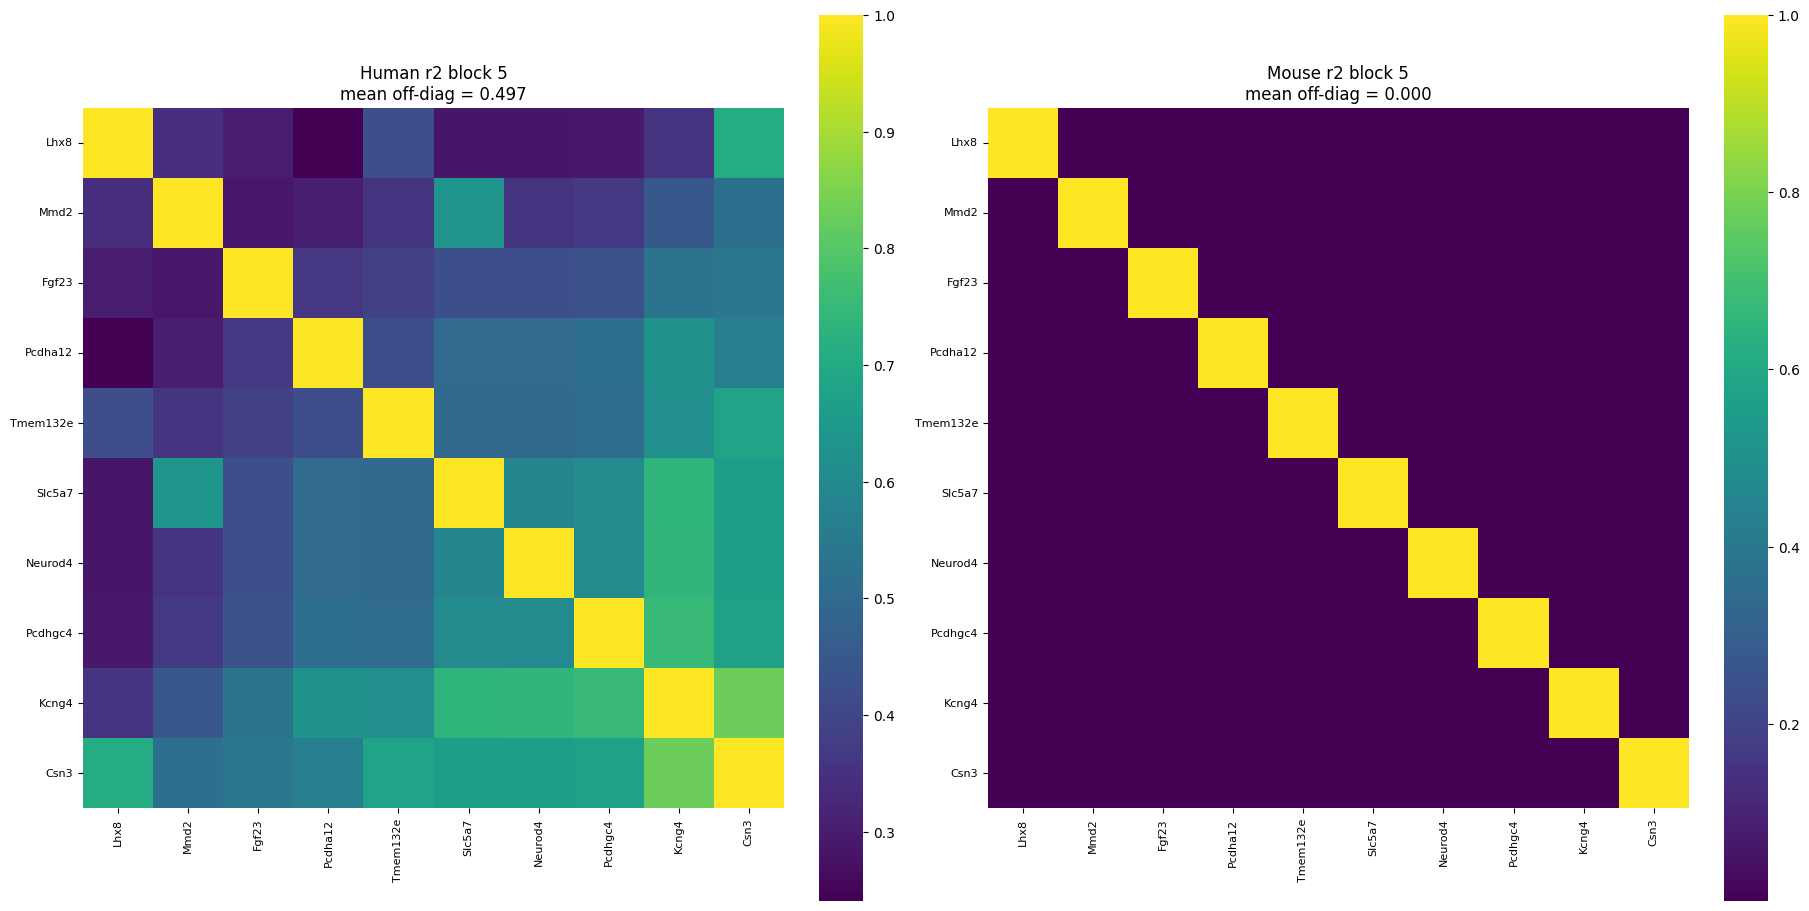

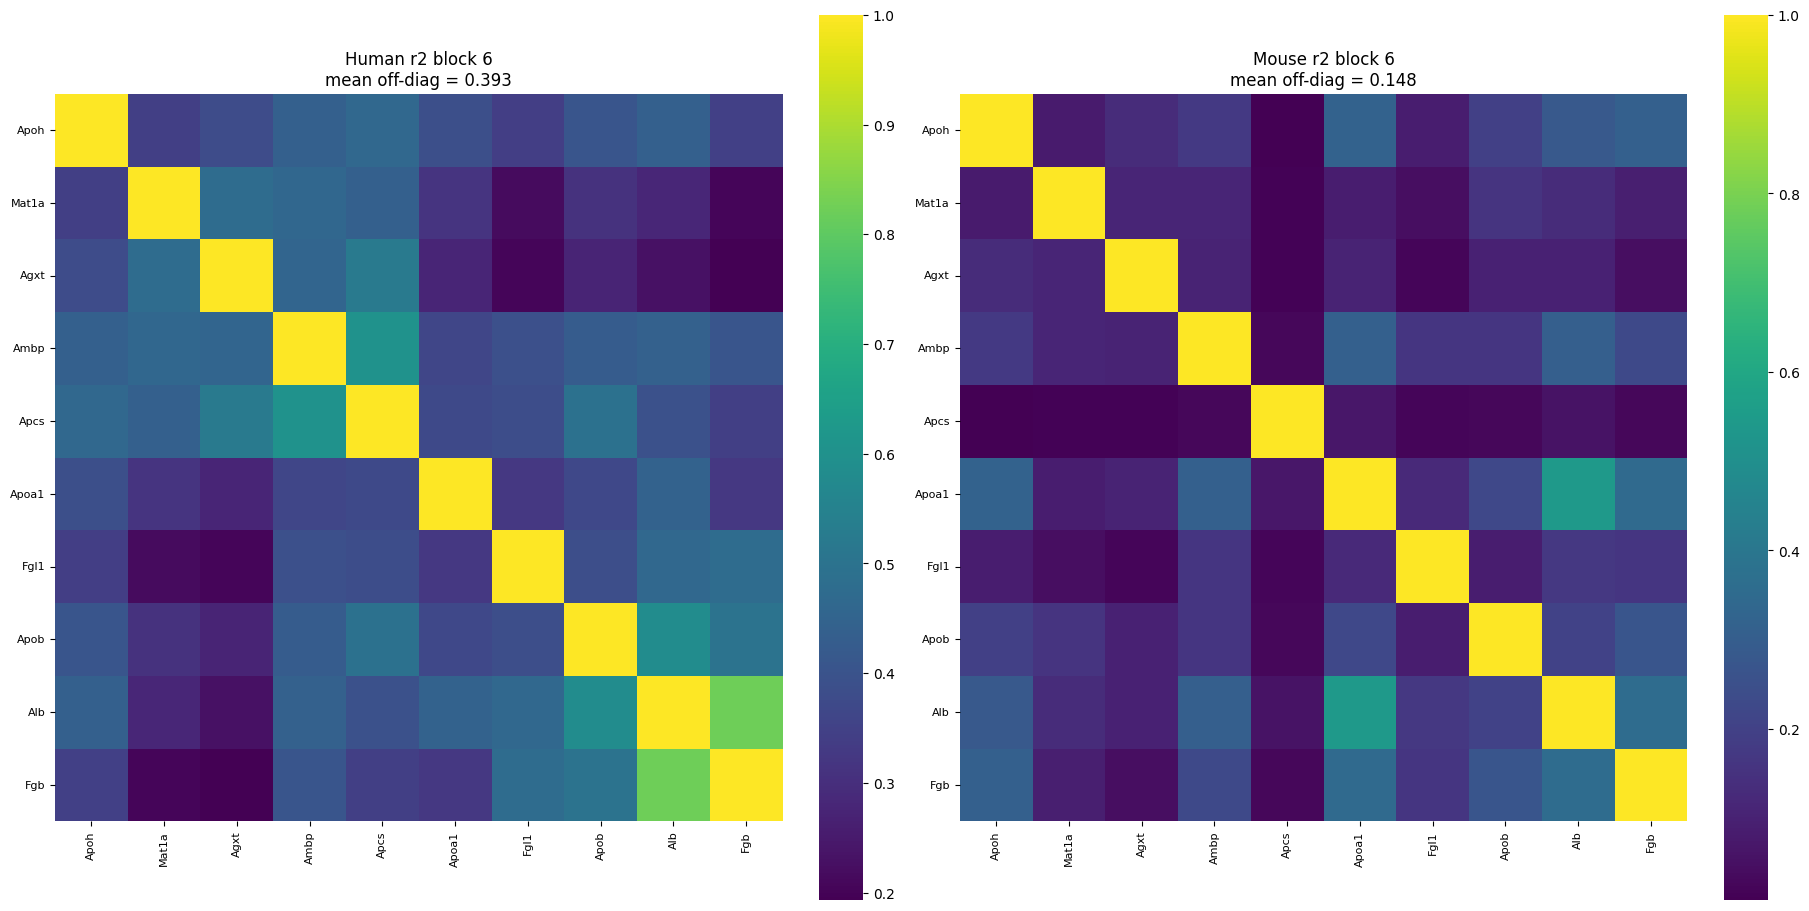

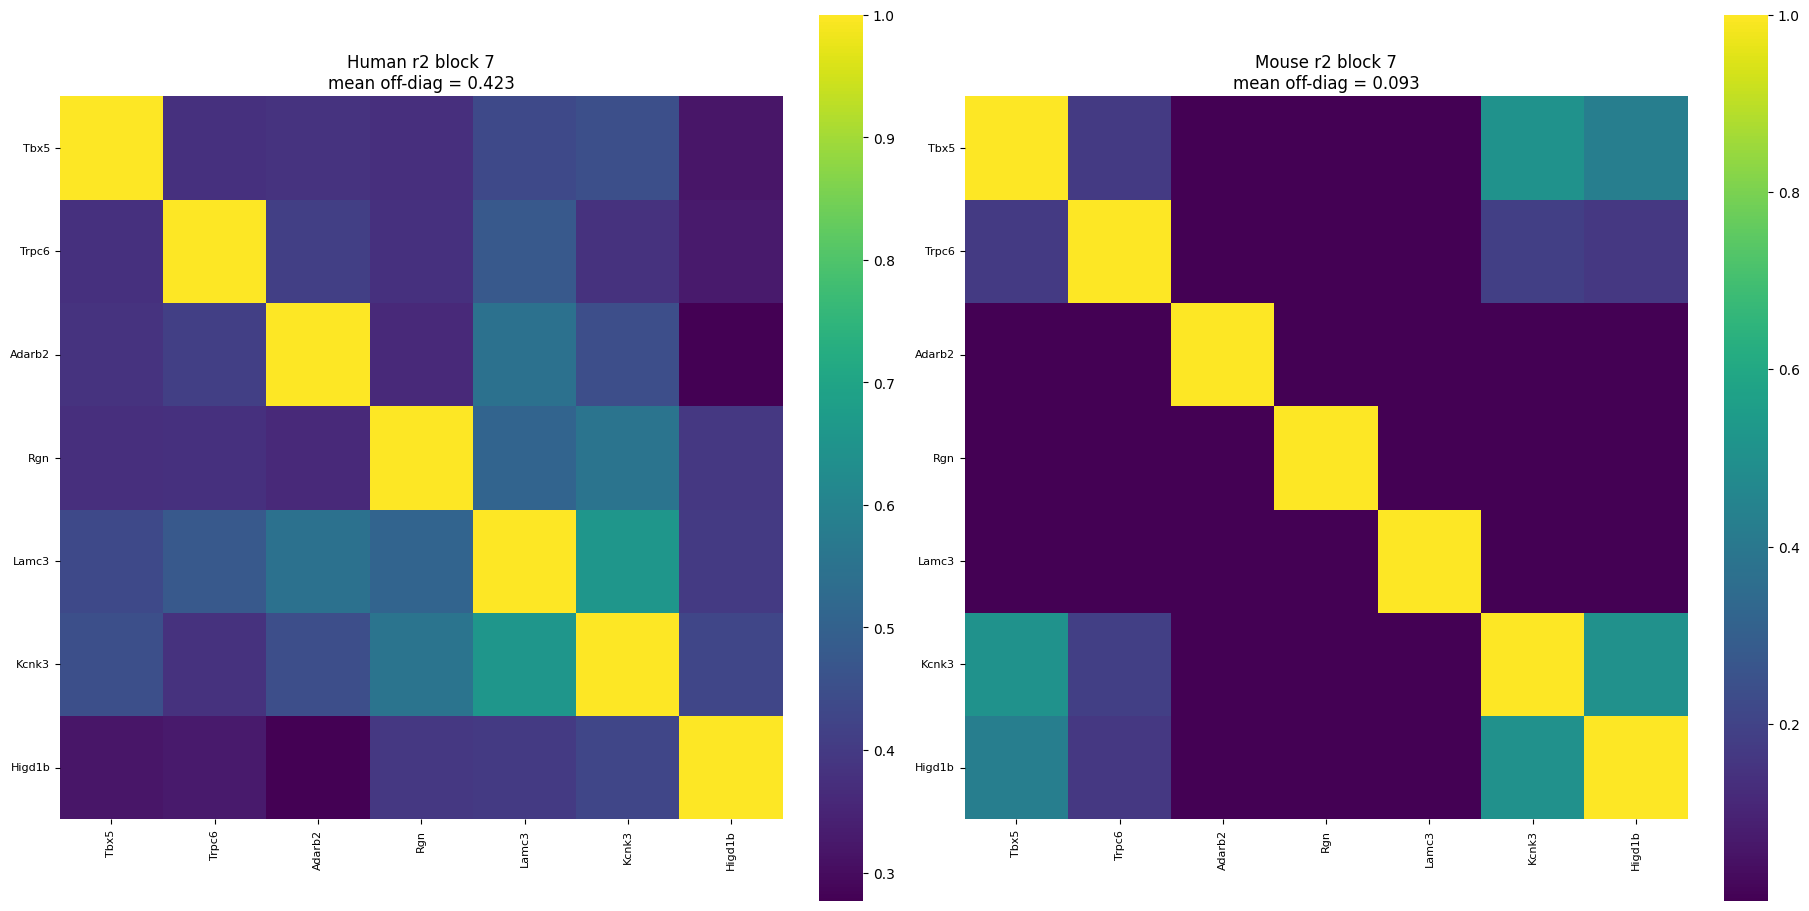

In [75]:
res = plot_paired_human_mouse_top_corr_subheatmaps(human_ortholog_corr_df, mouse_corrs, ortholog_df=ortholog_df, max_genes=20, max_panels=20, avg_corr_threshold=0.2)

In [53]:
for i in range(10):
    print(len(res['modules_mouse'][i]))

20
14
18
18
10
10
7


IndexError: list index out of range

In [54]:
def plot_paired_corr_clustermap(
    human_corrs_df,
    mouse_corrs_df,
    ortholog_df,
    *,
    human_value_col="r2",
    mouse_value_col="r2",
    genes=None,
    figsize=(18, 9),
    human_title="Human",
    mouse_title="Mouse",
):
    """
    Plot paired full correlation heatmaps for human and mouse side by side, using
    the human clustering order for both panels.

    Human genes are clustered using the human correlation matrix. The human axes are
    labeled with mouse ortholog gene names from `ortholog_df`, and the mouse panel
    uses the same label order.

    Parameters
    ----------
    human_corrs_df : pd.DataFrame
        Must contain columns 'g1', 'g2', and `human_value_col`.
        g1/g2 should be human Ensembl IDs.
    mouse_corrs_df : pd.DataFrame
        Must contain columns 'g1', 'g2', and `mouse_value_col`.
        g1/g2 should be mouse gene names.
    ortholog_df : pd.DataFrame
        Must contain columns:
          - 'human_ensembl_id'
          - 'mouse_gene_name'
    human_value_col : str
        Column to use for the human heatmap.
    mouse_value_col : str
        Column to use for the mouse heatmap.
    genes : list-like or None
        Optional subset of human Ensembl IDs to include.
    figsize : tuple
        Figure size for the combined figure.
    human_title : str
        Title for the human panel.
    mouse_title : str
        Title for the mouse panel.

    Returns
    -------
    dict with:
        'figure'        : matplotlib Figure
        'axes'          : array of Axes
        'human_matrix'  : full ordered human matrix
        'mouse_matrix'  : full ordered mouse matrix
        'ordered_genes' : ordered human Ensembl IDs
        'labels'        : displayed axis labels
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import squareform

    def build_symmetric_matrix(df, value_col):
        req = {"g1", "g2", value_col}
        missing = req - set(df.columns)
        if missing:
            raise KeyError(f"Missing required columns for {value_col!r}: {sorted(missing)}")

        x = df[["g1", "g2", value_col]].dropna().copy()
        if x.empty:
            raise ValueError(f"No non-null values found in column {value_col!r}.")

        x["g1"] = x["g1"].astype(str)
        x["g2"] = x["g2"].astype(str)

        mat_genes = pd.Index(sorted(set(x["g1"]).union(x["g2"])))
        mat = pd.DataFrame(np.nan, index=mat_genes, columns=mat_genes, dtype=float)

        for g1, g2, v in x.itertuples(index=False, name=None):
            mat.at[g1, g2] = float(v)
            mat.at[g2, g1] = float(v)

        np.fill_diagonal(mat.values, 1.0)
        return mat.fillna(0.0)

    req_ortho = {"human_ensembl_id", "mouse_gene_name"}
    missing_ortho = req_ortho - set(ortholog_df.columns)
    if missing_ortho:
        raise KeyError(f"ortholog_df missing required columns: {sorted(missing_ortho)}")

    ortho = ortholog_df[["human_ensembl_id", "mouse_gene_name"]].copy()
    ortho["human_ensembl_id"] = ortho["human_ensembl_id"].astype(str)
    ortho["mouse_gene_name"] = ortho["mouse_gene_name"].astype(str)
    ortho = ortho.drop_duplicates(subset=["human_ensembl_id"], keep="first")
    human_to_mouse_name = dict(zip(ortho["human_ensembl_id"], ortho["mouse_gene_name"]))

    human_mat = build_symmetric_matrix(human_corrs_df, human_value_col)
    mouse_mat = build_symmetric_matrix(mouse_corrs_df, mouse_value_col)

    if genes is not None:
        genes = [str(g) for g in genes]
        keep = [g for g in genes if g in human_mat.index]
        if len(keep) < 2:
            raise ValueError("Need at least 2 selected human genes present in human_corrs_df.")
        human_mat = human_mat.loc[keep, keep]

    dist = 1.0 - human_mat.values
    np.fill_diagonal(dist, 0.0)
    dist = np.clip(dist, 0.0, None)

    Z = linkage(squareform(dist, checks=False), method="average")
    order = leaves_list(Z)
    ordered_genes = list(human_mat.index[order])
    human_ord = human_mat.loc[ordered_genes, ordered_genes]

    raw_mouse_names = []
    for hid in ordered_genes:
        nm = human_to_mouse_name.get(str(hid), str(hid))
        if not nm or str(nm).strip().lower() == "nan":
            nm = str(hid)
        raw_mouse_names.append(str(nm))

    counts = pd.Series(raw_mouse_names).value_counts()
    labels = [
        f"{nm}|{hid}" if counts[nm] > 1 else nm
        for hid, nm in zip(ordered_genes, raw_mouse_names)
    ]

    human_ord = human_ord.copy()
    human_ord.index = labels
    human_ord.columns = labels

    mouse_ord = mouse_mat.reindex(index=raw_mouse_names, columns=raw_mouse_names).copy()
    mouse_ord = mouse_ord.fillna(0.0)
    for g in raw_mouse_names:
        if g in mouse_mat.index:
            mouse_ord.at[g, g] = 1.0
    mouse_ord.index = labels
    mouse_ord.columns = labels

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    for ax, sub, title, val_col in [
        (axes[0], human_ord, human_title, human_value_col),
        (axes[1], mouse_ord, mouse_title, mouse_value_col),
    ]:
        sns.heatmap(
            sub,
            ax=ax,
            cmap="viridis",
            square=True,
            xticklabels=True,
            yticklabels=True,
            cbar=True,
        )
        ax.set_xticks(np.arange(len(sub.columns)) + 0.5)
        ax.set_yticks(np.arange(len(sub.index)) + 0.5)
        ax.set_xticklabels(sub.columns, rotation=90, fontsize=8)
        ax.set_yticklabels(sub.index, rotation=0, fontsize=8)
        ax.set_title(f"{title} clustered correlation heatmap ({val_col})")
        ax.set_xlabel("")
        ax.set_ylabel("")

    return {
        "figure": fig,
        "axes": axes,
        "human_matrix": human_ord,
        "mouse_matrix": mouse_ord,
        "ordered_genes": ordered_genes,
        "labels": labels,
    }

{'figure': <Figure size 1800x900 with 4 Axes>,
 'axes': array([<Axes: title={'center': 'Human clustered correlation heatmap (r2)'}>,
        <Axes: title={'center': 'Mouse clustered correlation heatmap (r2)'}>],
       dtype=object),
 'human_matrix':                2210016L21Rik     Ms4a5        Ccdc27         Il23a      Il1a  \
 2210016L21Rik       1.000000  0.000923  4.721560e-06  2.235333e-04  0.000129   
 Ms4a5               0.000923  1.000000  1.557053e-06  2.870930e-05  0.000004   
 Ccdc27              0.000005  0.000002  1.000000e+00  6.624901e-04  0.000003   
 Il23a               0.000224  0.000029  6.624901e-04  1.000000e+00  0.007839   
 Il1a                0.000129  0.000004  3.298601e-06  7.839346e-03  1.000000   
 ...                      ...       ...           ...           ...       ...   
 Clec11a             0.001311  0.000030  9.513829e-04  3.003398e-04  0.000167   
 Prok2               0.000033  0.000061  7.683667e-05  4.394772e-04  0.000028   
 Ereg                

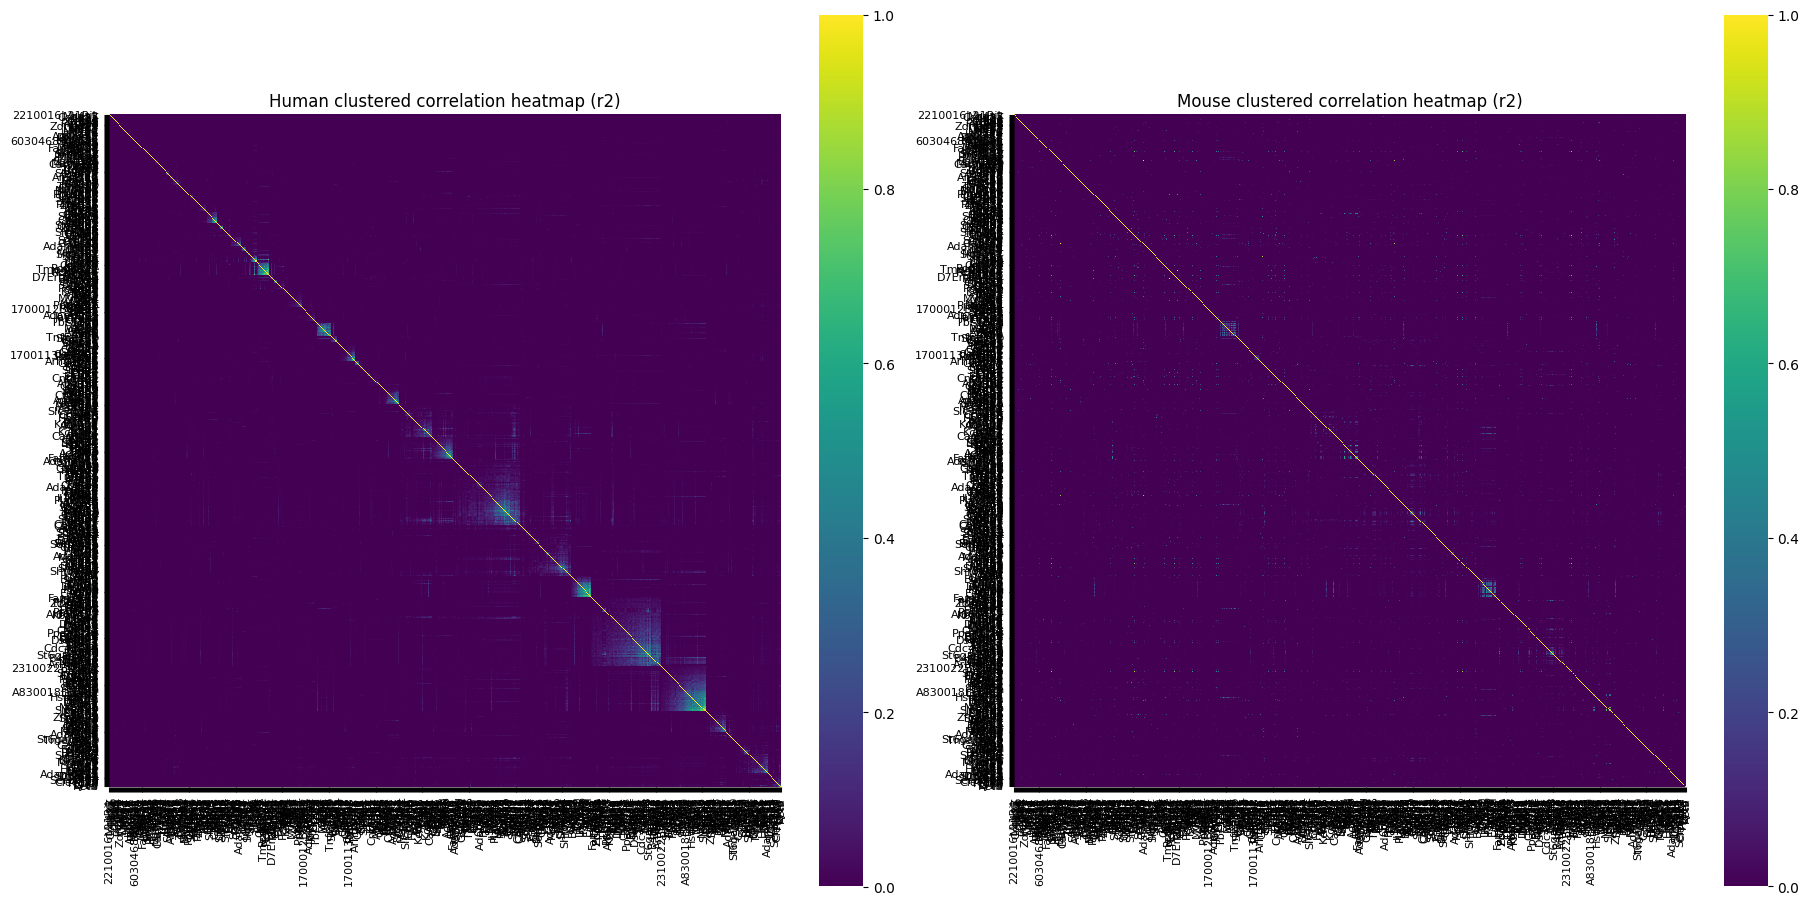

In [55]:
plot_paired_corr_clustermap(human_ortholog_corr_df, mouse_corrs, ortholog_df)

In [56]:
# Of highly correlated human pairs, how many are highly correlated in mouse?

def pct_human_high_corr_pairs_preserved_in_mouse(
    human_corrs_df,
    mouse_corrs_df,
    ortholog_df,
    *,
    human_r2_thresh=0.5,
    mouse_r2_thresh=None,
    human_value_col="r2",
    mouse_value_col="r2",
):
    """
    Compute what fraction of highly correlated human gene pairs are also highly
    correlated in their mouse ortholog pair.

    Parameters
    ----------
    human_corrs_df : pd.DataFrame
        Must contain columns ['g1', 'g2', human_value_col], where g1/g2 are
        human Ensembl IDs.
    mouse_corrs_df : pd.DataFrame
        Must contain columns ['g1', 'g2', mouse_value_col], where g1/g2 are
        mouse gene names.
    ortholog_df : pd.DataFrame
        Must contain columns:
          - 'human_ensembl_id'
          - 'mouse_gene_name'
    human_r2_thresh : float
        Threshold for calling a human pair highly correlated.
    mouse_r2_thresh : float or None
        Threshold for calling a mouse pair highly correlated. If None, uses the
        same value as `human_r2_thresh`.
    human_value_col : str
        Correlation column in human_corrs_df.
    mouse_value_col : str
        Correlation column in mouse_corrs_df.

    Returns
    -------
    dict with:
        'n_human_high_corr_pairs'
        'n_with_mouse_ortholog_pair'
        'n_mouse_ortholog_pairs_high_corr'
        'pct_mouse_ortholog_pairs_high_corr'
    """
    import numpy as np
    import pandas as pd

    if mouse_r2_thresh is None:
        mouse_r2_thresh = human_r2_thresh

    req_h = {"g1", "g2", human_value_col}
    req_m = {"g1", "g2", mouse_value_col}
    req_o = {"human_ensembl_id", "mouse_gene_name"}

    missing_h = req_h - set(human_corrs_df.columns)
    missing_m = req_m - set(mouse_corrs_df.columns)
    missing_o = req_o - set(ortholog_df.columns)

    if missing_h:
        raise KeyError(f"human_corrs_df missing required columns: {sorted(missing_h)}")
    if missing_m:
        raise KeyError(f"mouse_corrs_df missing required columns: {sorted(missing_m)}")
    if missing_o:
        raise KeyError(f"ortholog_df missing required columns: {sorted(missing_o)}")

    # Human Ensembl -> mouse ortholog name
    ortho = ortholog_df[["human_ensembl_id", "mouse_gene_name"]].copy()
    ortho["human_ensembl_id"] = ortho["human_ensembl_id"].astype(str)
    ortho["mouse_gene_name"] = ortho["mouse_gene_name"].astype(str)
    ortho = ortho.dropna().drop_duplicates(subset=["human_ensembl_id"], keep="first")
    human_to_mouse = dict(zip(ortho["human_ensembl_id"], ortho["mouse_gene_name"]))

    # Mouse pair -> r2 lookup
    mouse_pairs = mouse_corrs_df[["g1", "g2", mouse_value_col]].dropna().copy()
    mouse_lookup = {}
    for g1, g2, r2 in mouse_pairs.itertuples(index=False, name=None):
        key = tuple(sorted((str(g1), str(g2))))
        mouse_lookup[key] = float(r2)

    # Filter human high-correlation pairs
    human_pairs = human_corrs_df[["g1", "g2", human_value_col]].dropna().copy()
    human_pairs["g1"] = human_pairs["g1"].astype(str)
    human_pairs["g2"] = human_pairs["g2"].astype(str)

    human_high = human_pairs[human_pairs[human_value_col] > human_r2_thresh].copy()
    n_human_high = len(human_high)

    n_with_mouse_ortholog_pair = 0
    n_mouse_high = 0

    for h1, h2, _ in human_high.itertuples(index=False, name=None):
        m1 = human_to_mouse.get(h1)
        m2 = human_to_mouse.get(h2)

        if m1 is None or m2 is None:
            continue

        key = tuple(sorted((m1, m2)))
        if key not in mouse_lookup:
            continue

        n_with_mouse_ortholog_pair += 1
        if mouse_lookup[key] > mouse_r2_thresh:
            n_mouse_high += 1

    pct = (
        100.0 * n_mouse_high / n_with_mouse_ortholog_pair
        if n_with_mouse_ortholog_pair > 0 else np.nan
    )

    print(f"Highly correlated human gene pairs (r2 > {human_r2_thresh}): {n_human_high}")
    print(f"Human pairs with mouse ortholog pair found: {n_with_mouse_ortholog_pair}")
    print(
        f"Mouse ortholog pairs also highly correlated "
        f"(r2 > {mouse_r2_thresh}): {n_mouse_high} / {n_with_mouse_ortholog_pair} "
        f"({pct:.2f}%)"
        if n_with_mouse_ortholog_pair > 0
        else "Mouse ortholog pairs also highly correlated: 0 / 0 (NaN%)"
    )

    return {
        "n_human_high_corr_pairs": n_human_high,
        "n_with_mouse_ortholog_pair": n_with_mouse_ortholog_pair,
        "n_mouse_ortholog_pairs_high_corr": n_mouse_high,
        "pct_mouse_ortholog_pairs_high_corr": pct,
    }

In [73]:
res = pct_human_high_corr_pairs_preserved_in_mouse(human_ortholog_corr_df, mouse_corrs, ortholog_df,
    human_r2_thresh=0.0,
)

Highly correlated human gene pairs (r2 > 0.0): 235641
Human pairs with mouse ortholog pair found: 224785
Mouse ortholog pairs also highly correlated (r2 > 0.0): 224785 / 224785 (100.00%)


In [76]:
def top_mutually_correlated_ortholog_pairs(
    human_corrs_df,
    mouse_corrs_df,
    ortholog_df,
    *,
    top_n=100,
    human_value_col="r2",
    mouse_value_col="r2",
):
    """
    Return the top mutually correlated ortholog gene pairs ranked by:
        min(human_r2, mouse_r2)

    Assumes:
      - human_corrs_df['g1'] / ['g2'] are human Ensembl IDs
      - mouse_corrs_df['g1'] / ['g2'] are mouse gene names
      - ortholog_df contains:
            'human_ensembl_id'
            'mouse_gene_name'

    Output columns:
      - h_g1, h_g2          : human Ensembl IDs
      - m_g1, m_g2          : mouse ortholog gene names
      - human_r2
      - mouse_r2
      - min_r2              : ranking metric
    """
    import pandas as pd
    import numpy as np

    req_h = {"g1", "g2", human_value_col}
    req_m = {"g1", "g2", mouse_value_col}
    req_o = {"human_ensembl_id", "mouse_gene_name"}

    missing_h = req_h - set(human_corrs_df.columns)
    missing_m = req_m - set(mouse_corrs_df.columns)
    missing_o = req_o - set(ortholog_df.columns)

    if missing_h:
        raise KeyError(f"human_corrs_df missing required columns: {sorted(missing_h)}")
    if missing_m:
        raise KeyError(f"mouse_corrs_df missing required columns: {sorted(missing_m)}")
    if missing_o:
        raise KeyError(f"ortholog_df missing required columns: {sorted(missing_o)}")

    # Human Ensembl -> mouse gene name
    ortho = ortholog_df[["human_ensembl_id", "mouse_gene_name"]].copy()
    ortho["human_ensembl_id"] = ortho["human_ensembl_id"].astype(str)
    ortho["mouse_gene_name"] = ortho["mouse_gene_name"].astype(str)
    ortho = ortho.dropna().drop_duplicates(subset=["human_ensembl_id"], keep="first")
    h2m = dict(zip(ortho["human_ensembl_id"], ortho["mouse_gene_name"]))

    # Mouse pair lookup
    mouse_lookup = {}
    for g1, g2, r2 in mouse_corrs_df[["g1", "g2", mouse_value_col]].dropna().itertuples(index=False, name=None):
        key = tuple(sorted((str(g1), str(g2))))
        mouse_lookup[key] = float(r2)

    rows = []
    for h1, h2, hr2 in human_corrs_df[["g1", "g2", human_value_col]].dropna().itertuples(index=False, name=None):
        h1 = str(h1)
        h2 = str(h2)

        m1 = h2m.get(h1)
        m2 = h2m.get(h2)
        if m1 is None or m2 is None:
            continue

        mouse_key = tuple(sorted((str(m1), str(m2))))
        mr2 = mouse_lookup.get(mouse_key)
        if mr2 is None:
            continue

        hr2 = float(hr2)
        rows.append(
            {
                "h_g1": h1,
                "h_g2": h2,
                "m_g1": mouse_key[0],
                "m_g2": mouse_key[1],
                "human_r2": hr2,
                "mouse_r2": mr2,
                "min_r2": min(hr2, mr2),
            }
        )

    if not rows:
        return pd.DataFrame(
            columns=["h_g1", "h_g2", "m_g1", "m_g2", "human_r2", "mouse_r2", "min_r2"]
        )

    out = pd.DataFrame(rows)

    # Deduplicate just in case
    out["human_pair"] = out.apply(lambda r: tuple(sorted((r["h_g1"], r["h_g2"]))), axis=1)
    out = (
        out.sort_values(["min_r2", "human_r2", "mouse_r2"], ascending=False)
           .drop_duplicates(subset=["human_pair"])
           .drop(columns=["human_pair"])
           .head(top_n)
           .reset_index(drop=True)
    )

    return out

In [82]:
top_mutually_correlated_ortholog_pairs(human_ortholog_corr_df, mouse_corrs, ortholog_df, top_n=100).head(50)

,h_g1,h_g2,m_g1,m_g2,human_r2,mouse_r2,min_r2
0,ENSG00000196260,ENSG00000157765,Sfta2,Slc34a2,0.896925,0.792300,0.792300
1,ENSG00000136352,ENSG00000196260,Nkx2-1,Sfta2,0.756593,0.756963,0.756593
2,ENSG00000136352,ENSG00000157765,Nkx2-1,Slc34a2,0.761762,0.701511,0.701511
3,ENSG00000160180,ENSG00000174992,Tff3,Zg16,0.633611,0.544923,0.544923
4,ENSG00000159251,ENSG00000106631,Actc1,Myl7,0.684430,0.521536,0.521536
5,ENSG00000159251,ENSG00000129991,Actc1,Tnni3,0.667192,0.494061,0.494061
6,ENSG00000159251,ENSG00000198125,Actc1,Mb,0.469555,0.565504,0.469555
7,ENSG00000198125,ENSG00000129991,Mb,Tnni3,0.508737,0.462196,0.462196
8,ENSG00000159251,ENSG00000197616,Actc1,Myh6,0.557466,0.462031,0.462031
9,ENSG00000171303,ENSG00000089225,Kcnk3,Tbx5,0.450490,0.511501,0.450490
